# Mount drive and clone the source repository
# Important Setup Instructions for Running the Code

To ensure compatibility with the `museval` library (which requires `numpy<2`), please follow these steps:

## 1. Uninstall the default NumPy version

Run the following command to uninstall the current version of NumPy:

In [ ]:
!pip uninstall -y numpy

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [ ]:
!pip install numpy==1.26.4 --no-cache-dir --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 128.6 MB/s eta 0:00:00


Before proceeding, **restart the Colab session** (no disconnect and delete data) to avoid conflicts with the existing dependencies.


In [ ]:
import os
from google.colab import drive, userdata
drive.mount('/content/drive', force_remount=True)

DRIVE_PATH: str = '/content/drive/MyDrive/Deep Learning/Project'
assert os.path.exists(DRIVE_PATH), "Create a shortcut to MyDrive to load the repository"


Mounted at /content/drive


In [ ]:
!rm -rf /content/LQVAE-separation
!git clone https://github.com/alessandroscifoni/LQVAE-separation.git /content/LQVAE-separation
assert os.path.exists('/content/LQVAE-separation/.git'), 'Error cloning the repository. See logs above for details'
!rm -rf ./jukebox && mv /content/LQVAE-separation/jukebox .
!rm -rf ./script && mv /content/LQVAE-separation/script .
# !rm -rf ./samples && mv /content/LQVAE-separation/samples .
!mv /content/LQVAE-separation/requirements.txt .
!rm -rf /content/LQVAE-separation  # We don't need the Git repo anymore

Cloning into '/content/LQVAE-separation'...
remote: Enumerating objects: 1176, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 1176 (delta 104), reused 99 (delta 62), pack-reused 1027 (from 1)
Receiving objects: 100% (1176/1176), 15.17 MiB | 13.21 MiB/s, done.
Resolving deltas: 100% (623/623), done.


In [ ]:
%load_ext autoreload
%autoreload 1
%aimport jukebox
import jukebox

In [ ]:
!pip install torchinfo

In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.3/466.3 kB 20.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 40.6 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=e9ed87ad93e8e9ba7708c70d6e9be0b00d377c88ba5277b7385cb87021ca6da3
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
  Created wheel for mpi4py: filename=mpi4p

In [ ]:
# @title imports
import shutil
import random
import numpy as np
import torch as t
from torchinfo import summary
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from jukebox.hparams import setup_hparams
from jukebox.vqvae.encdec import Encoder, Decoder
from jukebox.vqvae.resnet import Resnet, Resnet1D
from jukebox.utils.torch_utils import assert_shape, freeze_model, unfreeze_model
from jukebox.make_models import make_vqvae, make_prior
from jukebox.data.my_data_processor import DataProcessor
from jukebox.utils.audio_utils import audio_preprocess, audio_postprocess, save_wav, spectral_convergence, spectral_loss, multispectral_loss, audio_postprocess
from script.codebook_precalc import compute_sums
from jukebox.utils.audio_utils import calculate_bandwidth, plot_spectrogram
from jukebox.utils.logger import average_metrics
from script.bayesian_inference import separate
import torchaudio

# Data

In [ ]:
# !wget https://zenodo.org/records/4603870/files/babyslakh_16k.tar.gz

In [ ]:
!tar -xzf /content/drive/MyDrive/Deep\ Learning/Project/Dataset/babyslakh_16k.tar.gz
# !rm babyslakh_16k.tar.gz

In [ ]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
t.manual_seed(SEED)
if t.cuda.is_available():
    t.cuda.manual_seed(SEED)
    t.cuda.manual_seed_all(SEED)
    t.backends.cudnn.deterministic = True
    t.backends.cudnn.benchmark = False

def split_and_copy_dataset(source_path, destination_path, train_ratio=0.9):
    """
    Splits .wav files into train and test directories based on the given ratio.

    Parameters:
    - source_path (str): Path to the source dataset.
    - destination_path (str): Path to the destination directory.
    - train_ratio (float): Ratio of files to place in the train directory (default: 0.9).

    Returns:
    - None
    """
    # Create train and test directories
    train_path = os.path.join(destination_path, "train")
    test_path = os.path.join(destination_path, "test")
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    # Collect all .wav files and their parent directories
    all_files = []
    for track_dir in os.listdir(source_path):
      track_path = os.path.join(source_path, track_dir)
      if os.path.isdir(track_path):
        for song in os.listdir(track_path):
          track = os.path.join(track_path, song)
          if song.endswith(".wav"):
            all_files.append((track_path, song))
          elif os.path.isdir(track):
            for stem in os.listdir(track):
              if stem.endswith(".wav") and not stem.startswith("_") and not stem.startswith("."):
                all_files.append((track, stem))
    print(f"Total number of files: {len(all_files)}")
    # Shuffle the list of files
    random.shuffle(all_files)

    # Split the files into train and test sets
    split_index = int(len(all_files) * train_ratio)
    train_files = all_files[:split_index]
    test_files = all_files[split_index:]

    # Copy files to train directory
    for track_path, song in train_files:
        dst_path = os.path.join(train_path, os.path.basename(track_path))
        os.makedirs(dst_path, exist_ok=True)
        shutil.copy(os.path.join(track_path, song), os.path.join(dst_path, song))

    # Copy files to test directory
    for track_path, song in test_files:
        dst_path = os.path.join(test_path, os.path.basename(track_path))
        os.makedirs(dst_path, exist_ok=True)
        shutil.copy(os.path.join(track_path, song), os.path.join(dst_path, song))

    print(f"Files successfully split and copied to:\nTrain: {train_path}\nTest: {test_path}")

# Example usage:
source_path = "/content/babyslakh_16k/"
destination_path = "/content/babyslakh_16k_dataset/"
split_and_copy_dataset(source_path, destination_path)


Total number of files: 229
Files successfully split and copied to:
Train: /content/babyslakh_16k_dataset/train
Test: /content/babyslakh_16k_dataset/test


In [ ]:
data_processor = DataProcessor("/content/babyslakh_16k_dataset/train/","/content/babyslakh_16k_dataset/test/", batch_size=8)

Train Dir: /content/babyslakh_16k_dataset/train/
Found 36 audio files in /content/babyslakh_16k_dataset/train/
/content/babyslakh_16k_dataset/train/Track00013/mix.wav
/content/babyslakh_16k_dataset/train/Track00007/mix.wav
/content/babyslakh_16k_dataset/train/Track00019/mix.wav
/content/babyslakh_16k_dataset/train/Track00012/mix.wav
/content/babyslakh_16k_dataset/train/Track00015/mix.wav
/content/babyslakh_16k_dataset/train/Track00004/mix.wav
/content/babyslakh_16k_dataset/train/Track00002/mix.wav
/content/babyslakh_16k_dataset/train/Track00001/mix.wav
/content/babyslakh_16k_dataset/train/Track00009/mix.wav
/content/babyslakh_16k_dataset/train/Track00017/mix.wav
/content/babyslakh_16k_dataset/train/Track00006/mix.wav
/content/babyslakh_16k_dataset/train/Track00008/mix.wav
/content/babyslakh_16k_dataset/train/stems/S13.wav
/content/babyslakh_16k_dataset/train/stems/S05.wav
/content/babyslakh_16k_dataset/train/stems/S02.wav
/content/babyslakh_16k_dataset/train/stems/S00.wav
/content/baby

In [ ]:
train_dataloader = data_processor.train_loader
val_dataloader = data_processor.val_loader

# Restore the models

In [ ]:
path_vqvae = os.path.join(DRIVE_PATH, "LQVAE-separation/checkpoint_step_60001_latent.pth.tar")
path_prior_0 = os.path.join(DRIVE_PATH, "LQVAE-separation/checkpoint_drums_22050_latent_78_19k.pth.tar")
path_prior_1 = os.path.join(DRIVE_PATH, "LQVAE-separation/checkpoint_latest.pth.tar")
path_codebook = os.path.join(DRIVE_PATH, "LQVAE-separation/codebook_precalc_22050_latent.pt")

In [ ]:
device = "cuda"
raw_to_tokens = 64                               # Downsampling factor
levels = 3                                       # Number of levels
level = 2                                        # VQ-VAE Level on which separation is performed
sample_rate = 16000                              # Sample rate
downs_t = [2, 2, 2]                              # Downsampling factors
commit = 1.0                                     # Commit scale
sample_length = raw_to_tokens * sample_rate      # Sample length

In [ ]:
def make_my_vqvae(vqvae_path, config, device='cuda'):

    hps = setup_hparams(config, {
        "sample_length": sample_length,
        # "downs_t": downs_t, # default [2,2,2]
        "sr": sample_rate,
        "commit": commit,
        **({"restore_vqvae": vqvae_path} if vqvae_path else {"train":True})
    })


    print()

    hps.bandwidth = calculate_bandwidth(data_processor.train_dataset, hps)

    vqvae = make_vqvae(hps, device) # if vqvae_path, the model is already freezed



    return hps,vqvae #, hps_distilled,distilled_vqvae #, priors

In [ ]:
hps, vqvae = make_my_vqvae(path_vqvae, 'vqvae')

Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/LQVAE-separation/checkpoint_step_60001_latent.pth.tar', 'levels': 3, 'downs_t': (2, 2, 2), 'strides_t': (2, 2, 2), 'hvqvae_mult

In [ ]:
def make_my_prior(prior_path, device='cuda'):
  return make_prior(setup_hparams('small_prior', dict(levels=levels, level=level, labels=None,
                                                           restore_prior=prior_path, c_res=1, fp16_params=True,
                                                           n_ctx=8192)), vqvae, device)

In [ ]:
prior_0 = make_my_prior(path_prior_0)

Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '', 'levels': 3, 'downs_t': (1, 1), 'strides_t': (2, 2), 'hvqvae_multipliers': None, 'revival_threshold': 1.0, 'emb_width': 64, 'l_bins': 512, 'l_mu': 0.99, 'commit': 1.0, '

In [ ]:
prior_0

SimplePrior(
  (prior): ConditionalAutoregressive2D(
    (bottleneck): Bottleneck(
      (level_blocks): ModuleList(
        (0-2): 3 x BottleneckBlock()
      )
    )
    (x_embs): Linear(in_features=64, out_features=1024, bias=False)
    (x_emb_dropout): Dropout(p=0.0, inplace=False)
    (pos_emb): PositionEmbedding()
    (pos_emb_dropout): Dropout(p=0.0, inplace=False)
    (transformer): Transformer(
      (_attn_mods): ModuleList(
        (0-47): 48 x ResAttnBlock(
          (attn): FactoredAttention(
            (c_attn): Conv1D()
            (c_proj): Conv1D()
          )
          (ln_0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (c_fc): Conv1D()
            (c_proj): Conv1D()
          )
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (x_out): Linear(in_features=1024, out_features=2048, bias=False)
    (loss): CrossEntropyLoss()
  )
)

In [ ]:
prior_1 = make_my_prior(path_prior_1)

Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '', 'levels': 3, 'downs_t': (1, 1), 'strides_t': (2, 2), 'hvqvae_multipliers': None, 'revival_threshold': 1.0, 'emb_width': 64, 'l_bins': 512, 'l_mu': 0.99, 'commit': 1.0, '

In [ ]:
vqvae.encoders[2]

Encoder(
  (level_blocks): ModuleList(
    (0): EncoderConvBlock(
      (model): Sequential(
        (0): Sequential(
          (0): Conv1d(1, 32, kernel_size=(4,), stride=(2,), padding=(1,))
          (1): Resnet1D(
            (model): Sequential(
              (0): ResConv1DBlock(
                (model): Sequential(
                  (0): ReLU()
                  (1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
                  (2): ReLU()
                  (3): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
                )
              )
              (1): ResConv1DBlock(
                (model): Sequential(
                  (0): ReLU()
                  (1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(3,), dilation=(3,))
                  (2): ReLU()
                  (3): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
                )
              )
              (2): ResConv1DBlock(
                (model): Sequential(
                  (0): ReLU

# footprint

In [ ]:
total_params = sum(p.numel() for p in prior_0.parameters())
approx_non_zero_params = sum((p.abs() > 1e-4).sum().item() for p in prior_0.parameters())
approx_zero_params = total_params - approx_non_zero_params
sparsity = 100 * approx_zero_params / total_params

print(f"Total parameters: {total_params}")
print(f"Approximately non-zero parameters (threshold={1e-4}): {approx_non_zero_params}")
print(f"Approximately zero parameters: {approx_zero_params}")
print(f"Sparsity (threshold={1e-4}): {sparsity:.2f}%")

Total parameters: 161928192
Approximately non-zero parameters (threshold=0.0001): 161659409
Approximately zero parameters: 268783
Sparsity (threshold=0.0001): 0.17%


In [ ]:
total_params = sum(p.numel() for p in prior_1.parameters())
approx_non_zero_params = sum((p.abs() > 1e-4).sum().item() for p in prior_1.parameters())
approx_zero_params = total_params - approx_non_zero_params
sparsity = 100 * approx_zero_params / total_params

print(f"Total parameters: {total_params}")
print(f"Approximately non-zero parameters (threshold={1e-4}): {approx_non_zero_params}")
print(f"Approximately zero parameters: {approx_zero_params}")
print(f"Sparsity (threshold={1e-4}): {sparsity:.2f}%")

Total parameters: 161928192
Approximately non-zero parameters (threshold=0.0001): 161556732
Approximately zero parameters: 371460
Sparsity (threshold=0.0001): 0.23%


In [ ]:
total_params = sum(p.numel() for p in vqvae.parameters())
approx_non_zero_params = sum((p.abs() > 1e-4).sum().item() for p in vqvae.parameters())
approx_zero_params = total_params - approx_non_zero_params
sparsity = 100 * approx_zero_params / total_params

print(f"Total parameters: {total_params}")
print(f"Approximately non-zero parameters (threshold={1e-4}): {approx_non_zero_params}")
print(f"Approximately zero parameters: {approx_zero_params}")
print(f"Sparsity (threshold={1e-4}): {sparsity:.2f}%")

Total parameters: 1105603
Approximately non-zero parameters (threshold=0.0001): 1104201
Approximately zero parameters: 1402
Sparsity (threshold=0.0001): 0.13%


In [ ]:
total_params = sum(p.numel() for p in vqvae.encoders.parameters())
approx_non_zero_params = sum((p.abs() > 1e-4).sum().item() for p in vqvae.encoders.parameters())
approx_zero_params = total_params - approx_non_zero_params
sparsity = 100 * approx_zero_params / total_params

print(f"Total parameters: {total_params}")
print(f"Approximately non-zero parameters (threshold={1e-4}): {approx_non_zero_params}")
print(f"Approximately zero parameters: {approx_zero_params}")
print(f"Sparsity (threshold={1e-4}): {sparsity:.2f}%")

Total parameters: 536384
Approximately non-zero parameters (threshold=0.0001): 535822
Approximately zero parameters: 562
Sparsity (threshold=0.0001): 0.10%


In [ ]:
total_params = sum(p.numel() for p in vqvae.bottleneck.parameters())
if total_params == 0:
    print("No parameters in the bottleneck!")
else:
    approx_non_zero_params = sum((p.abs() > 1e-4).sum().item() for p in vqvae.bottleneck.parameters())
    approx_zero_params = total_params - approx_non_zero_params
    sparsity = 100 * approx_zero_params / total_params

    print(f"Total parameters: {total_params}")
    print(f"Approximately non-zero parameters (threshold={1e-4}): {approx_non_zero_params}")
    print(f"Approximately zero parameters: {approx_zero_params}")
    print(f"Sparsity (threshold={1e-4}): {sparsity:.2f}%")

In [ ]:
total_params = sum(p.numel() for p in vqvae.decoders.parameters())
approx_non_zero_params = sum((p.abs() > 1e-4).sum().item() for p in vqvae.decoders.parameters())
approx_zero_params = total_params - approx_non_zero_params
sparsity = 100 * approx_zero_params / total_params

print(f"Total parameters: {total_params}")
print(f"Approximately non-zero parameters (threshold={1e-4}): {approx_non_zero_params}")
print(f"Approximately zero parameters: {approx_zero_params}")
print(f"Sparsity (threshold={1e-4}): {sparsity:.2f}%")

Total parameters: 569219
Approximately non-zero parameters (threshold=0.0001): 568379
Approximately zero parameters: 840
Sparsity (threshold=0.0001): 0.15%


I chose to distill the VQVAE model due to the large size of the priors and the limited computational capabilities of Colab.

Now, using the distilled architecture I defined in **hparams.py** (the original file from Jukebox), I want to assess the reduction in the number of parameters.

In [ ]:
hps_distilled, distilled_vqvae = make_my_vqvae(None, 'distilled_vqvae')

Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 4), 'hvqvae_multipliers': (1, 0.5, 0.5), 'revival_threshold': 1.0, 'emb_width': 64, 'l_bins': 2048, 'l_mu': 0.99, 

In [ ]:
distilled_vqvae.encoders[2]

Encoder(
  (level_blocks): ModuleList(
    (0): EncoderConvBlock(
      (model): Sequential(
        (0): Sequential(
          (0): Conv1d(1, 16, kernel_size=(8,), stride=(4,), padding=(2,))
          (1): Resnet1D(
            (model): Sequential(
              (0): ResConv1DBlock(
                (model): Sequential(
                  (0): ReLU()
                  (1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
                  (2): ReLU()
                  (3): Conv1d(16, 16, kernel_size=(1,), stride=(1,))
                )
              )
              (1): ResConv1DBlock(
                (model): Sequential(
                  (0): ReLU()
                  (1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
                  (2): ReLU()
                  (3): Conv1d(16, 16, kernel_size=(1,), stride=(1,))
                )
              )
            )
          )
        )
        (1): Conv1d(16, 64, kernel_size=(3,), stride=(1,), padd

In [ ]:
summary(distilled_vqvae.encoders[0], input_size=(1, 1, 80000), depth=8)

Layer (type:depth-idx)                                       Output Shape              Param #
Encoder                                                      [1, 64, 20000]            --
├─ModuleList: 1-1                                            --                        --
│    └─EncoderConvBlock: 2-1                                 [1, 64, 20000]            --
│    │    └─Sequential: 3-1                                  [1, 64, 20000]            --
│    │    │    └─Sequential: 4-1                             [1, 32, 20000]            --
│    │    │    │    └─Conv1d: 5-1                            [1, 32, 20000]            288
│    │    │    │    └─Resnet1D: 5-2                          [1, 32, 20000]            --
│    │    │    │    │    └─Sequential: 6-1                   [1, 32, 20000]            --
│    │    │    │    │    │    └─ResConv1DBlock: 7-1          [1, 32, 20000]            --
│    │    │    │    │    │    │    └─Sequential: 8-1         [1, 32, 20000]            4,160
│

In [ ]:
total_params = sum(p.numel() for p in distilled_vqvae.parameters())
approx_non_zero_params = sum((p.abs() > 1e-4).sum().item() for p in distilled_vqvae.parameters())
approx_zero_params = total_params - approx_non_zero_params
sparsity = 100 * approx_zero_params / total_params

print(f"Total parameters: {total_params}")
print(f"Approximately non-zero parameters (threshold={1e-4}): {approx_non_zero_params}")
print(f"Approximately zero parameters: {approx_zero_params}")
print(f"Sparsity (threshold={1e-4}): {sparsity:.2f}%")

Total parameters: 181411
Approximately non-zero parameters (threshold=0.0001): 181150
Approximately zero parameters: 261
Sparsity (threshold=0.0001): 0.14%


In [ ]:
total_params_student = sum(p.numel() for p in distilled_vqvae.parameters())
total_params_teacher = sum(p.numel() for p in vqvae.parameters())
print(f"total_params_student is {total_params_student} and total_params_teacher is {total_params_teacher}")
print(f"We reduced the number of parameters of {100 - (total_params_student / total_params_teacher * 100):.2f}%")

total_params_student is 181411 and total_params_teacher is 1105603
We reduced the number of parameters of 83.59%


# Match the output of the 2 models

We want that the outputs of the encoder, bottleneck, and decoder of the student model match the teacher's outputs, because we want to enforce the student model to give the same output

In [ ]:
sample = next(iter(val_dataloader))
sample = sample.to(device)
sample.shape

torch.Size([8, 1, 80000])

In [ ]:
# x_in = vqvae.preprocess(sample) #it is already [N,C,T]
xs = []
for level in range(vqvae.levels):
    encoder = vqvae.encoders[level]
    x_out = encoder(sample)
    print(f"Encoder output shape at level {level}: {x_out[-1].shape}")
    xs.append(x_out[-1])

zs, xs_quantised, commit_losses, quantiser_metrics = vqvae.bottleneck(xs)

x_outs = []
for level in range(vqvae.levels):
    decoder = vqvae.decoders[level]
    x_out = decoder(xs_quantised[level:level+1], all_levels=False)
    print(f"Decoder output shape at level {level}: {x_out.shape}")
    x_outs.append(x_out)

Encoder output shape at level 0: torch.Size([8, 64, 20000])
Encoder output shape at level 1: torch.Size([8, 64, 5000])
Encoder output shape at level 2: torch.Size([8, 64, 1250])
output Decoder level 0 shape: torch.Size([8, 64, 80000])
Decoder output shape at level 0: torch.Size([8, 1, 80000])
output Decoder level 1 shape: torch.Size([8, 64, 20000])
output Decoder level 0 shape: torch.Size([8, 64, 80000])
Decoder output shape at level 1: torch.Size([8, 1, 80000])
output Decoder level 2 shape: torch.Size([8, 64, 5000])
output Decoder level 1 shape: torch.Size([8, 64, 20000])
output Decoder level 0 shape: torch.Size([8, 64, 80000])
Decoder output shape at level 2: torch.Size([8, 1, 80000])


In [ ]:
# x_in = distilled_vqvae.preprocess(sample)
xs = []
for level in range(distilled_vqvae.levels):
    encoder = distilled_vqvae.encoders[level]
    x_out = encoder(sample)
    print(f"Encoder output shape at level {level}: {x_out[-1].shape}")
    xs.append(x_out[-1])

zs, xs_quantised, commit_losses, quantiser_metrics = distilled_vqvae.bottleneck(xs)

x_outs = []
for level in range(distilled_vqvae.levels):
    decoder = distilled_vqvae.decoders[level]
    x_out = decoder(xs_quantised[level:level+1], all_levels=False)
    print(f"Decoder output shape at level {level}: {x_out.shape}")
    x_outs.append(x_out)

Encoder output shape at level 0: torch.Size([16, 64, 20000])
Encoder output shape at level 1: torch.Size([16, 64, 5000])
Encoder output shape at level 2: torch.Size([16, 64, 1250])
Decoder output shape at level 0: torch.Size([16, 1, 80000])
Decoder output shape at level 1: torch.Size([16, 1, 80000])
Decoder output shape at level 2: torch.Size([16, 1, 80000])


# Training the full student encoder
In this phase, I will train **three different student encoders** using a knowledge distillation approach. Remember VQ-VAE architectures use multiple encoders at different resolutions to capture hierarchical features.

The pre-trained VQ-VAE acts as the teacher, while the distilled VQ-VAE serves as the student.

To ensure that only the student model learns, I **freeze** the teacher model for all its parameters. The student model **remains trainable**, and I optimize it using an **MSE-based loss function** that minimizes the difference between the teacher and student encoder outputs.

In [ ]:
teacher = vqvae  # Pre-trained teacher
student = distilled_vqvae

# Teacher is frozen
freeze_model(teacher)
assert all(p.requires_grad == False for p in teacher.parameters()), "Teacher model should be frozen"

freeze_model(student)
for param in student.encoders.parameters():
    param.requires_grad = True
assert all(p.requires_grad for p in student.encoders.parameters()), "Student encoders should be trainable"
assert all(p.requires_grad == False for p in student.bottleneck.parameters()), "The bottleneck should be frozen"
assert all(p.requires_grad == False for p in student.decoders.parameters()), "The decoders should be frozen"

# Optimizer for student
optimizer = optim.Adam(student.parameters(), lr=1e-3)
num_epochs = 30

# Placeholder for storing losses for each epoch
losses = []
losses_val = []

# Distillation training loop
for epoch in range(num_epochs):
    student.train()
    running_loss = 0  # To track loss for this epoch

    # Using tqdm for the progress bar
    loop = tqdm(enumerate(train_dataloader), total=len(train_dataloader), leave=True)
    for batch_idx, inputs in loop:
        inputs = vqvae.preprocess(inputs) # teacher.enc already calls preprocess
        inputs = inputs.to(device)

        # Forward pass through teacher and student
        with t.no_grad():
            teacher_outputs = teacher.enc(inputs)  # Teacher's outputs
        student_outputs = student.enc(inputs)  # Student's outputs

        # Compute loss for each encoder and aggregate
        total_loss = sum(F.mse_loss(teacher_outputs[i], student_outputs[i]) for i in range(3)) / 3

        # Backpropagation and optimization
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += total_loss.item()

        # Update progress bar with loss and epoch information
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=total_loss.item())
    # Calculate average loss for the epoch
    avg_loss = running_loss / len(train_dataloader)
    losses.append(avg_loss)

    # Print loss for this epoch
    tqdm.write(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}")

    ####### VALIDATION ########
    student.eval()
    val_loss = 0
    with t.no_grad():
        for data in val_dataloader:
            data = teacher.preprocess(data)
            data = data.to(device=device)

            teacher_outputs = teacher.enc(data)  # Teacher's outputs

            student_outputs = student.enc(data)  # Student's outputs

            total_loss = sum(F.mse_loss(teacher_outputs[i], student_outputs[i]) for i in range(3)) / 3

            val_loss += total_loss.item()
        # Calculate average loss for the epoch
        avg_val_loss = val_loss / len(val_dataloader)
        losses_val.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss:.4f}")
        # if avg val_loss is better than the one before, save the model
        if epoch == 0:
            # create directory if not exist
            os.makedirs(f"{DRIVE_PATH}/checkpoint3", exist_ok=True)
            best_loss = avg_val_loss
            t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint3/trained_distilled_vqvae.pth")
        elif avg_val_loss < best_loss:
            best_loss = avg_val_loss
            t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint3/trained_distilled_vqvae.pth")


Epoch [1/30]: 100%|██████████| 95/95 [01:36<00:00,  1.02s/it, loss=2.45]

Epoch [1/30], Average Loss: 5.6148


Validation Loss: 2.4933


Epoch [2/30]: 100%|██████████| 95/95 [01:36<00:00,  1.02s/it, loss=2.15]

Epoch [2/30], Average Loss: 2.0256


...

Epoch [29/30], Average Loss: 0.9040


Validation Loss: 0.8760


Epoch [30/30]: 100%|██████████| 95/95 [01:28<00:00,  1.08it/s, loss=1.16]

Epoch [30/30], Average Loss: 0.9100


Validation Loss: 0.8769


Best validation loss: 0.8760


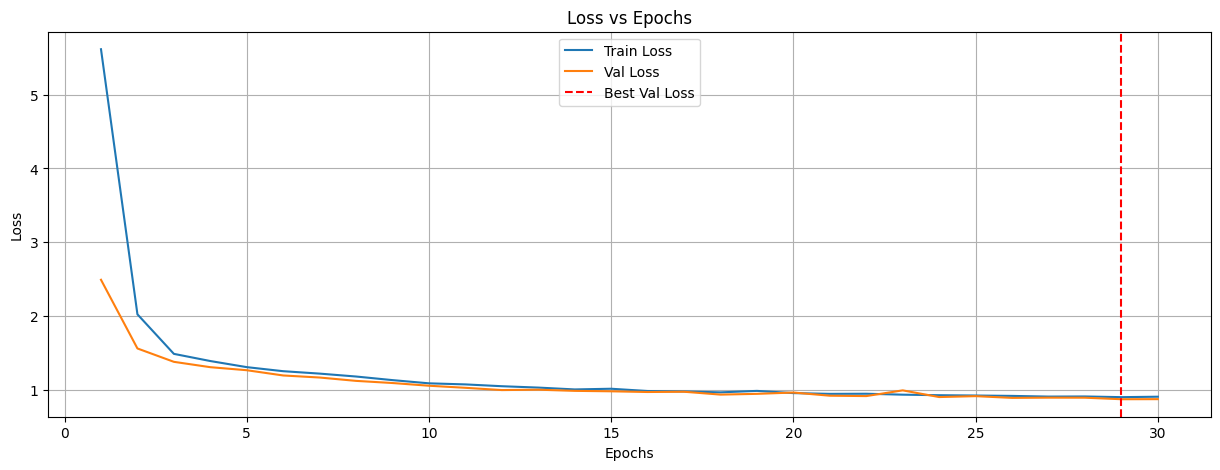

In [ ]:
print(f"Best validation loss: {best_loss:.4f}")
index_best = losses_val.index(best_loss)

plt.figure(figsize=(15, 5))
plt.plot(range(1,num_epochs+1), losses, label="Train Loss")
plt.plot(range(1,num_epochs+1), losses_val, label="Val Loss")
plt.axvline(index_best+1, color='r', linestyle='--', label="Best Val Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

# Testing the encoder
Since we don't have the entire distill network, we will test the encoder's functionality by feeding its output into the teacher model and observing the results.

In [ ]:
trained_distilled_vqvae_path = f"{DRIVE_PATH}/checkpoint3/Copia di trained_distilled_vqvae.pth"
hps_distilled, student = make_my_vqvae(trained_distilled_vqvae_path, 'distilled_vqvae')
assert all(p.requires_grad == False for p in student.parameters()), "Student model should be frozen"

Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint3/Copia di trained_distilled_vqvae.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 4), 'hvqvae_multiplie

In [ ]:
student = student.to(device)

In [ ]:
sample = next(iter(val_dataloader))[0]
sample = sample.to(device)
sample.shape

torch.Size([1, 80000])

In [ ]:
sample = sample.unsqueeze(0)
sample.shape

torch.Size([1, 1, 80000])

In [ ]:
with t.no_grad():
  # teacher result one
  N = sample.shape[0]

  # Encode/Quantizzazione/Decode of single sources
  # x_in = vqvae.preprocess(sample)
  xs2 = []
  for level in range(student.levels):
      encoder = student.encoders[level]
      x_out = encoder(sample)
      xs2.append(x_out[-1])
  xs = []
  for level in range(vqvae.levels):
      encoder = vqvae.encoders[level]
      x_out = encoder(sample)
      xs.append(x_out[-1])


  #l2 distance between output encoders
  print(f"the l2 distance between output encoder at level 0 is {F.mse_loss(xs2[0], xs[0])}")
  print(f"the l2 distance between output encoder at level 1 is {F.mse_loss(xs2[1], xs[1])}")
  print(f"the l2 distance between output encoder at level 2 is {F.mse_loss(xs2[2], xs[2])}")


  #bottleneck
  zs2, xs_quantised2, commit_losses2, quantiser_metrics2 = vqvae.bottleneck(xs2)

  zs, xs_quantised, commit_losses, quantiser_metrics = vqvae.bottleneck(xs)

  #l2 distance between output bottlenecks
  print(f"the l2 distance between output bottlenecks at level 0 is {F.mse_loss(xs_quantised2[0], xs_quantised[0])}")
  print(f"the l2 distance between output bottlenecks at level 1 is {F.mse_loss(xs_quantised2[1], xs_quantised[1])}")
  print(f"the l2 distance between output bottlenecks at level 2 is {F.mse_loss(xs_quantised2[2], xs_quantised[2])}")
  #decode

  x_outs2=[]
  for level in range(vqvae.levels):
      decoder = vqvae.decoders[level]
      x_out = decoder(xs_quantised2[level:level+1], all_levels=False)
      # print(f"Decoder output shape at level {level}: {x_out.shape}")  # Print the shape
      x_outs2.append(x_out)

  x_outs=[]
  for level in range(vqvae.levels):
      decoder = vqvae.decoders[level]
      x_out = decoder(xs_quantised[level:level+1], all_levels=False)
      # print(f"Decoder output shape at level {level}: {x_out.shape}")  # Print the shape
      x_outs.append(x_out)

  #l2 distance between output decoder
  print(f"the l2 distance between output decoder at level 0 is {F.mse_loss(x_outs2[0] , x_outs[0])}")
  print(f"the l2 distance between output decoder at level 1 is {F.mse_loss(x_outs2[1] , x_outs[1])}")
  print(f"the l2 distance between output decoder at level 2 is {F.mse_loss(x_outs2[2] , x_outs[2])}")


  dst_path = "/content/teacher_reconstruction"
  os.makedirs(dst_path, exist_ok=True)
  torchaudio.save(f'{dst_path}/teacher_rec_0.wav', x_outs[0].cpu().squeeze(0), sample_rate=hps.sr)
  torchaudio.save(f'{dst_path}/teacher_rec_1.wav', x_outs[1].cpu().squeeze(0), sample_rate=hps.sr)
  torchaudio.save(f'{dst_path}/teacher_rec_2.wav', x_outs[2].cpu().squeeze(0), sample_rate=hps.sr)
  dst_path = "/content/student_reconstruction"
  os.makedirs(dst_path, exist_ok=True)
  torchaudio.save(f'{dst_path}/student_rec_0.wav', x_outs2[0].cpu().squeeze(0), sample_rate=hps.sr)
  torchaudio.save(f'{dst_path}/student_rec_1.wav', x_outs2[1].cpu().squeeze(0), sample_rate=hps.sr)
  torchaudio.save(f'{dst_path}/student_rec_2.wav', x_outs2[2].cpu().squeeze(0), sample_rate=hps.sr)

the l2 distance between output encoder at level 0 is 0.004107212647795677
the l2 distance between output encoder at level 1 is 0.00028949594707228243
the l2 distance between output encoder at level 2 is 0.006465013604611158
the l2 distance between output bottlenecks at level 0 is 0.004881145898252726
the l2 distance between output bottlenecks at level 1 is 0.0002108285843860358
the l2 distance between output bottlenecks at level 2 is 0.004214880988001823
the l2 distance between output decoder at level 0 is 1.8771003169604228e-06
the l2 distance between output decoder at level 1 is 8.304237297807049e-08
the l2 distance between output decoder at level 2 is 2.5904680001076485e-07


In [ ]:
import os
from IPython.display import display, HTML

teacher_rec = "/content/teacher_reconstruction/teacher_rec_0.wav"
student_rec = "/content/student_reconstruction/student_rec_0.wav"

# Check if file exists
if os.path.exists(teacher_rec):
    print(f"File found: {teacher_rec}")
else:
    print(f"File NOT found: {teacher_rec}")

from IPython.display import Audio, display

display(Audio(teacher_rec, autoplay=False))
display(Audio(student_rec, autoplay=False))

File found: /content/teacher_reconstruction/teacher_rec_0.wav


### Analysis: Is the Student Encoder Learning?

The goal of this analysis is to evaluate if the **student model's encoder** is effectively learning by comparing its outputs to those of the **teacher model** at different levels of processing:

- The **student encoder** is learning effectively, as the **L2 distances** at all levels are relatively small.
- But, **levels 0 and 2** show higher L2 distances, meaning the student encoder is still not perfectly aligned with the teacher.
- The **decoder's near-identical outputs** suggest that even if there are small differences in the encoded representations, the impact on the final reconstruction is minimal.


# Train the full student decoder
Now, we train only the decoder, using the output from the teacher's bottleneck as input.

In [ ]:
teacher = vqvae  # Pre-trained teacher
trained_distilled_vqvae_path = f"{DRIVE_PATH}/checkpoint3/Copia di trained_distilled_vqvae.pth"
hps_distilled, student = make_my_vqvae(trained_distilled_vqvae_path, 'distilled_vqvae')
student = student.to(device)
# Teacher is frozen
freeze_model(teacher)
assert all(p.requires_grad == False for p in teacher.parameters()), "Teacher model should be frozen"

freeze_model(student)
student.train() #unfreeze only the decoders to be sure that only they are trainable
for param in student.decoders.parameters():
    param.requires_grad = True
assert all(p.requires_grad for p in student.decoders.parameters()), "Student decoders should be trainable"
assert all(p.requires_grad == False for p in student.bottleneck.parameters()), "The bottleneck should be frozen"
assert all(p.requires_grad == False for p in student.encoders.parameters()), "The encoders should be frozen"

# Optimizer for student
optimizer = optim.Adam(student.parameters(), lr=1e-4)
num_epochs = 30

# Placeholder for storing losses for each epoch
losses = []
losses_val = []

# Distillation training loop
for epoch in range(num_epochs):
    student.train()
    running_loss = 0  # To track loss for this epoch

    # Using tqdm for the progress bar
    loop = tqdm(enumerate(train_dataloader), total=len(train_dataloader), leave=True)
    for batch_idx, inputs in loop:
        inputs = vqvae.preprocess(inputs)
        inputs= inputs.to(device)

        # Forward pass through teacher and student
        with t.no_grad():
            inputs = teacher.enc(inputs)
            _, xs_quantised, _, _ = teacher.bottleneck(inputs)
            teacher_outputs = teacher.dec(xs_quantised)  # Teacher's outputs

        student_outputs = student.dec(xs_quantised)  # Student's outputs

        # Compute loss for each encoder and aggregate
        loss_total = sum(F.mse_loss(teacher_outputs[i], student_outputs[i]) for i in range(3)) / 3

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss_total.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += loss_total.item()

        # Update progress bar with loss and epoch information
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss_total.item())
    # Calculate average loss for the epoch
    avg_loss = running_loss / len(train_dataloader)
    losses.append(avg_loss)

    # Print loss for this epoch
    tqdm.write(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.7f}")

    ####### VALIDATION ########
    student.eval()
    val_loss = 0
    with t.no_grad():
        for data in val_dataloader:
            data = vqvae.preprocess(data)
            data = data.to(device=device)



            inputs = teacher.enc(data)
            _, xs_quantised, _, _ = teacher.bottleneck(inputs)
            teacher_outputs = teacher.dec(xs_quantised)  # Teacher's outputs

            student_outputs = student.dec(xs_quantised)  # Student's outputs

            loss_total = sum(F.mse_loss(teacher_outputs[i], student_outputs[i]) for i in range(3)) / 3

            val_loss += loss_total.item()
        # Calculate average loss for the epoch
        avg_val_loss = val_loss / len(val_dataloader)
        losses_val.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss:.7f}")
        # if avg val_loss is better than the one before, save the model
        if epoch == 0:
            # create directory if not exist
            os.makedirs(f"{DRIVE_PATH}/checkpoint3", exist_ok=True)
            best_loss = avg_val_loss
            t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint3/trained_distilled_vqvae.pth")
        elif avg_val_loss < best_loss:
            best_loss = avg_val_loss
            t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint3/trained_distilled_vqvae.pth")


Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint3/Copia di trained_distilled_vqvae.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 4), 'hvqvae_multiplie

Epoch [1/30]: 100%|██████████| 99/99 [01:55<00:00,  1.17s/it, loss=0.000172]

Epoch [1/30], Average Loss: 0.0033575


Validation Loss: 0.0006670


Epoch [2/30]: 100%|██████████| 99/99 [01:54<00:00,  1.16s/it, loss=2.08e-5]

...

Epoch [29/30], Average Loss: 0.0000624


Validation Loss: 0.0000649


Epoch [30/30]: 100%|██████████| 99/99 [01:54<00:00,  1.16s/it, loss=5.34e-5]

Epoch [30/30], Average Loss: 0.0000591


Validation Loss: 0.0000569


Best validation loss: 0.0001


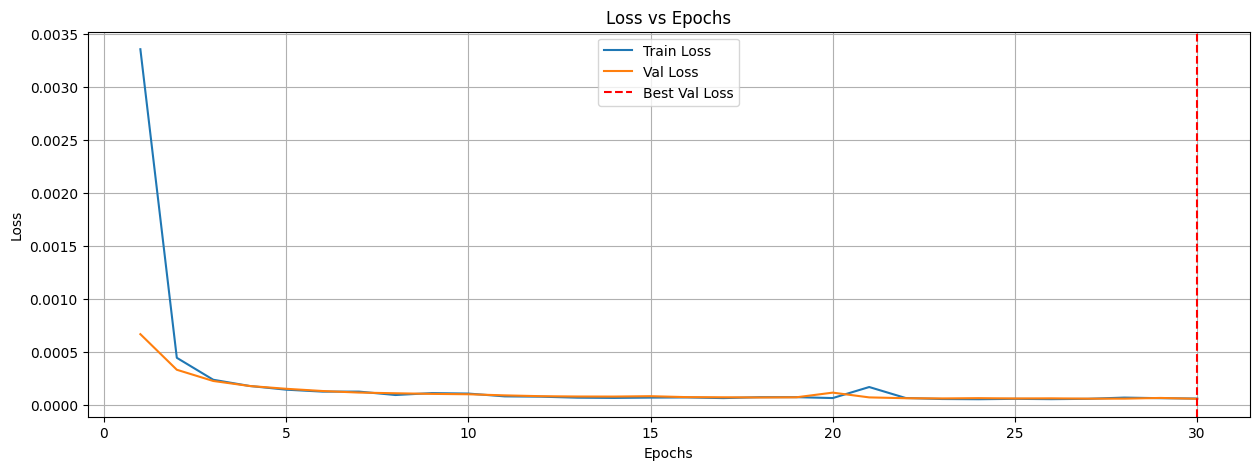

In [ ]:
print(f"Best validation loss: {best_loss:.4f}")
index_best = losses_val.index(best_loss)

plt.figure(figsize=(15, 5))
plt.plot(range(1,num_epochs+1), losses, label="Train Loss")
plt.plot(range(1,num_epochs+1), losses_val, label="Val Loss")
plt.axvline(index_best+1, color='r', linestyle='--', label="Best Val Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

#Save the entire model
Since the bottleneck of the student has the same structure of the teacher, because as we decided earlier, it doesn't contribute too much to the number of weights, we clone it so we can save the model

In [ ]:
trained_distilled_vqvae_path = f"{DRIVE_PATH}/checkpoint3/Copia post dec di trained_distilled_vqvae.pth"
hps_distilled, student = make_my_vqvae(trained_distilled_vqvae_path, 'distilled_vqvae')

Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint3/trained_distilled_vqvae.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 4), 'hvqvae_multipliers': (1, 

In [ ]:
student.bottleneck.load_state_dict(vqvae.bottleneck.state_dict())

<All keys matched successfully>

In [ ]:
t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint3/final_trained_distilled_vqvae.pth")

Ensure that the bottleneck is no longer initialized to zero

In [ ]:
student.bottleneck.level_blocks[0].k

tensor([[-9.6656e-03, -2.7916e-01, -4.4164e-01,  ...,  2.7771e-01,
          1.1782e-01, -3.0854e-02],
        [-6.6617e-01, -2.5840e+00,  6.9158e-01,  ..., -1.3368e+00,
         -2.3094e+00,  8.0365e-01],
        [ 2.8700e-01,  4.8602e-01, -9.0452e-01,  ...,  9.5586e-01,
          1.0925e+00, -3.2017e-01],
        ...,
        [-3.9973e-01, -1.5612e+00,  3.2561e-01,  ..., -5.9814e-01,
         -1.1230e+00,  5.2341e-01],
        [ 1.0220e-01,  3.9853e-02, -6.0182e-02,  ..., -1.3305e-03,
          7.9732e-02, -1.3434e-02],
        [-4.5365e-01, -1.7022e-01,  6.3790e-02,  ..., -1.2723e-01,
         -2.4867e-01,  1.2429e-01]], device='cuda:0')

# Train the student alone, without the supervision of the teacher

Can the student with a smaller architecture perform well or better than itself but with the supervision of the teacher?

In [ ]:
hps_alone_student, alone_student = make_my_vqvae(None, "distilled_vqvae")

unfreeze_model(alone_student)
assert all(p.requires_grad for p in alone_student.parameters()), "Student model should be trainable"

# Optimizer for student
optimizer = optim.Adam(alone_student.parameters(), lr=1e-3)
num_epochs = 30

# Placeholder for storing losses for each epoch
losses = []
losses_val = []

# Distillation training loop
for epoch in range(num_epochs):
    alone_student.train()
    running_loss = 0  # To track loss for this epoch

    # Using tqdm for the progress bar
    loop = tqdm(enumerate(train_dataloader), total=len(train_dataloader), leave=True)
    for batch_idx, inputs in loop:
        inputs = alone_student.preprocess(inputs)
        inputs= inputs.to(device)

        x_out, loss, metrics = alone_student(inputs, hps_alone_student)  # Student's outputs

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()

        # Apply gradient clipping
        t.nn.utils.clip_grad_norm_(alone_student.parameters(), max_norm=1.0)

        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Update progress bar with loss and epoch information
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())
    # Calculate average loss for the epoch
    avg_loss = running_loss / batch_idx + 1
    losses.append(avg_loss)

    # Print loss for this epoch
    tqdm.write(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}")

    ####### VALIDATION ########
    alone_student.eval()
    val_loss = 0
    with t.no_grad():
        for batch_idx, inputs in enumerate(val_dataloader):
            inputs = alone_student.preprocess(inputs)
            inputs = inputs.to(device=device)

            x_out, loss, metrics = alone_student(inputs,hps_alone_student)  # Student's outputs

            val_loss += loss.item()
        # Calculate average loss for the epoch
        avg_val_loss = val_loss / batch_idx + 1
        losses_val.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss:.4f}")
        # if avg val_loss is better than the one before, save the model
        if epoch == 0:
            # create directory if not exist
            os.makedirs(f"{DRIVE_PATH}/checkpoint", exist_ok=True)
            best_loss = avg_val_loss
            t.save(alone_student.state_dict(), f"{DRIVE_PATH}/checkpoint/trained_student_alone.pth")
        elif avg_val_loss < best_loss:
            best_loss = avg_val_loss
            t.save(alone_student.state_dict(), f"{DRIVE_PATH}/checkpoint/trained_student_alone.pth")


Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 4), 'hvqvae_multipliers': (1, 0.5, 0.5), 'revival_threshold': 1.0, 'emb_width': 64, 'l_bins': 2048, 'l_mu': 0.99, 

Epoch [1/30]: 100%|██████████| 191/191 [02:34<00:00,  1.23it/s, loss=1.57]

Epoch [1/30], Average Loss: 3.0324


Validation Loss: 2.7838


Epoch [2/30]: 100%|██████████| 191/191 [02:34<00:00,  1.23it/s, loss=1.25]

...

Epoch [29/30], Average Loss: 1.7940


Validation Loss: 1.9025


Epoch [30/30]: 100%|██████████| 191/191 [02:33<00:00,  1.24it/s, loss=0.875]

Epoch [30/30], Average Loss: 1.7877


Validation Loss: 1.9064


Best validation loss: 1.9018


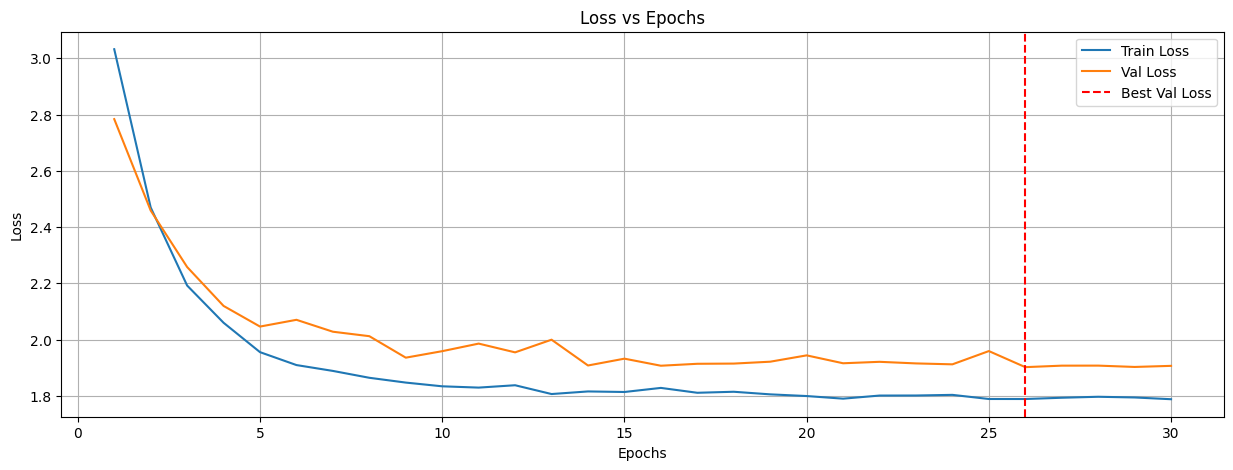

In [ ]:
print(f"Best validation loss: {best_loss:.4f}")
index_best = losses_val.index(best_loss)

plt.figure(figsize=(15, 5))
plt.plot(range(1,num_epochs+1), losses, label="Train Loss")
plt.plot(range(1,num_epochs+1), losses_val, label="Val Loss")
plt.axvline(index_best+1, color='r', linestyle='--', label="Best Val Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

#Evaluation of the performance(OLD)
Let's assess distilled and student_alone performances by comparing it to the teacher model in terms of accuracy and efficiency.

In [ ]:
trained_distilled_vqvae_path = f"{DRIVE_PATH}/checkpoint3/final_trained_distilled_vqvae.pth"
trained_student_alone_path = f"{DRIVE_PATH}/checkpoint3/trained_student_alone.pth"
hps_distilled, distilled_vqvae = make_my_vqvae(trained_distilled_vqvae_path, 'distilled_vqvae')
hps_student_alone, student_alone = make_my_vqvae(trained_student_alone_path, 'distilled_vqvae')

Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint3/final_trained_distilled_vqvae.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 4), 'hvqvae_multipliers'

In [ ]:
batch = next(iter(val_dataloader))
batch = batch.to(device)
batch = vqvae.preprocess(batch)

In [ ]:
@t.no_grad()
def evaluate(model, batch, hps):
  return model(batch, hps)

In [ ]:
%timeit evaluate(vqvae, batch, hps)

Reconstruction loss: 1.02 - Spectral loss: 0.75 - Multispectral loss: 0.48 - Commit loss: 10.94 - Latent loss: 0.81
Reconstruction loss: 1.02 - Spectral loss: 0.75 - Multispectral loss: 0.48 - Commit loss: 10.94 - Latent loss: 0.81
Reconstruction loss: 1.02 - Spectral loss: 0.75 - Multispectral loss: 0.48 - Commit loss: 10.94 - Latent loss: 0.81
Reconstruction loss: 1.02 - Spectral loss: 0.75 - Multispectral loss: 0.48 - Commit loss: 10.94 - Latent loss: 0.81
Reconstruction loss: 1.02 - Spectral loss: 0.75 - Multispectral loss: 0.48 - Commit loss: 10.94 - Latent loss: 0.81
Reconstruction loss: 1.02 - Spectral loss: 0.75 - Multispectral loss: 0.48 - Commit loss: 10.94 - Latent loss: 0.81
Reconstruction loss: 1.02 - Spectral loss: 0.75 - Multispectral loss: 0.48 - Commit loss: 10.94 - Latent loss: 0.81
Reconstruction loss: 1.02 - Spectral loss: 0.75 - Multispectral loss: 0.48 - Commit loss: 10.94 - Latent loss: 0.81
1.54 s ± 25.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit evaluate(distilled_vqvae, batch, hps_distilled)

Reconstruction loss: 3.28 - Spectral loss: 3.15 - Multispectral loss: 1.95 - Commit loss: 8.90 - Latent loss: 0.81
Reconstruction loss: 3.28 - Spectral loss: 3.15 - Multispectral loss: 1.95 - Commit loss: 8.90 - Latent loss: 0.81
Reconstruction loss: 3.28 - Spectral loss: 3.15 - Multispectral loss: 1.95 - Commit loss: 8.90 - Latent loss: 0.81
Reconstruction loss: 3.28 - Spectral loss: 3.15 - Multispectral loss: 1.95 - Commit loss: 8.90 - Latent loss: 0.81
Reconstruction loss: 3.28 - Spectral loss: 3.15 - Multispectral loss: 1.95 - Commit loss: 8.90 - Latent loss: 0.81
Reconstruction loss: 3.28 - Spectral loss: 3.15 - Multispectral loss: 1.95 - Commit loss: 8.90 - Latent loss: 0.81
Reconstruction loss: 3.28 - Spectral loss: 3.15 - Multispectral loss: 1.95 - Commit loss: 8.90 - Latent loss: 0.81
Reconstruction loss: 3.28 - Spectral loss: 3.15 - Multispectral loss: 1.95 - Commit loss: 8.90 - Latent loss: 0.81
663 ms ± 960 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit evaluate(student_alone, batch, hps_student_alone)

Reconstruction loss: 0.69 - Spectral loss: 0.41 - Multispectral loss: 0.25 - Commit loss: 0.10 - Latent loss: 0.06
Reconstruction loss: 0.69 - Spectral loss: 0.41 - Multispectral loss: 0.25 - Commit loss: 0.10 - Latent loss: 0.06
Reconstruction loss: 0.69 - Spectral loss: 0.41 - Multispectral loss: 0.25 - Commit loss: 0.10 - Latent loss: 0.06
Reconstruction loss: 0.69 - Spectral loss: 0.41 - Multispectral loss: 0.25 - Commit loss: 0.10 - Latent loss: 0.06
Reconstruction loss: 0.69 - Spectral loss: 0.41 - Multispectral loss: 0.25 - Commit loss: 0.10 - Latent loss: 0.06
Reconstruction loss: 0.69 - Spectral loss: 0.41 - Multispectral loss: 0.25 - Commit loss: 0.10 - Latent loss: 0.06
Reconstruction loss: 0.69 - Spectral loss: 0.41 - Multispectral loss: 0.25 - Commit loss: 0.10 - Latent loss: 0.06
Reconstruction loss: 0.69 - Spectral loss: 0.41 - Multispectral loss: 0.25 - Commit loss: 0.10 - Latent loss: 0.06
669 ms ± 1.11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
with t.no_grad():
  x_out2, loss2, metrics2 = distilled_vqvae(batch,hps_distilled)
  x_out, loss, metrics = vqvae(batch,hps)
  x_out3, loss3, metrics3 = student_alone(batch,hps_student_alone)
  print(x_out[1])
  print(hps_distilled.sr)
  dst_path = "/content/reconstruction"
  os.makedirs(dst_path, exist_ok=True)
  torchaudio.save(f'{dst_path}/teacher_rec_0.wav', x_out[1].cpu().permute(1,0), sample_rate=hps.sr)
  torchaudio.save(f'{dst_path}/distilled_vqvae_rec_0.wav', x_out2[1].cpu().permute(1,0), sample_rate=hps_distilled.sr)
  torchaudio.save(f'{dst_path}/student_alone_rec_0.wav', x_out3[1].cpu().permute(1,0), sample_rate=hps_distilled.sr)



Reconstruction loss: 3.28 - Spectral loss: 3.15 - Multispectral loss: 1.95 - Commit loss: 8.90 - Latent loss: 0.81
Reconstruction loss: 1.02 - Spectral loss: 0.75 - Multispectral loss: 0.48 - Commit loss: 10.94 - Latent loss: 0.81
Reconstruction loss: 0.69 - Spectral loss: 0.41 - Multispectral loss: 0.25 - Commit loss: 0.10 - Latent loss: 0.06
tensor([[ 0.1001],
        [ 0.1139],
        [ 0.0993],
        ...,
        [-0.1112],
        [-0.1018],
        [-0.0866]], device='cuda:0')
16000


In [ ]:
import os
from IPython.display import display, HTML

teacher_rec = "/content/reconstruction/teacher_rec_0.wav"
distilled_vqvae_rec = "/content/reconstruction/distilled_vqvae_rec_0.wav"
student_alone_rec = "/content/reconstruction/student_alone_rec_0.wav"

# Check if file exists
if os.path.exists(teacher_rec):
    print(f"File found: {teacher_rec}")
else:
    print(f"File NOT found: {teacher_rec}")

from IPython.display import Audio, display

display(Audio(teacher_rec, autoplay=False))
display(Audio(distilled_vqvae_rec, autoplay=False))
display(Audio(student_alone_rec, autoplay=False))

File found: /content/reconstruction/teacher_rec_0.wav


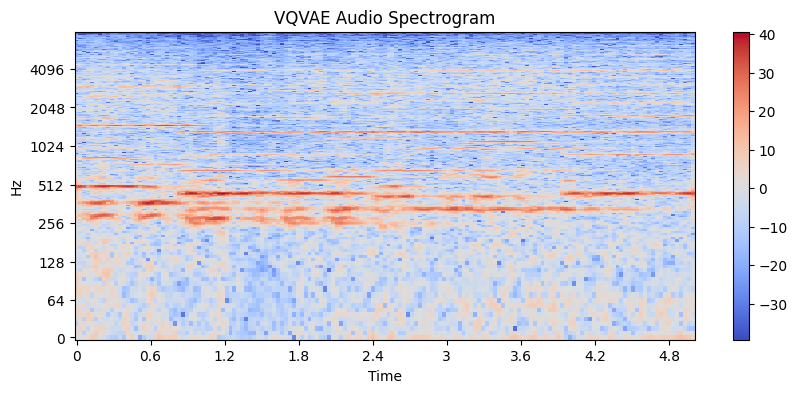

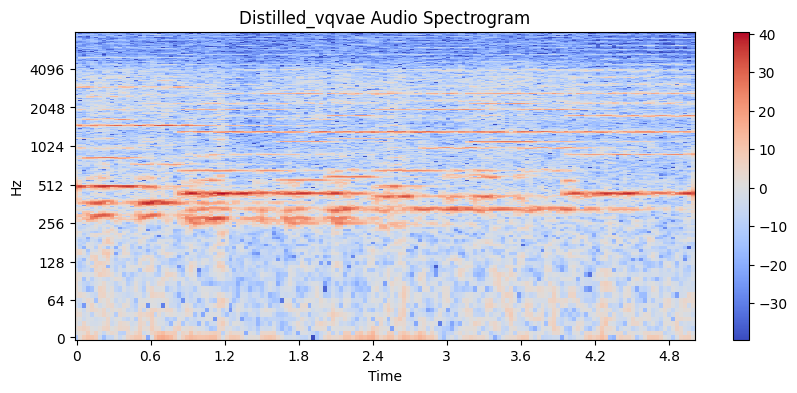

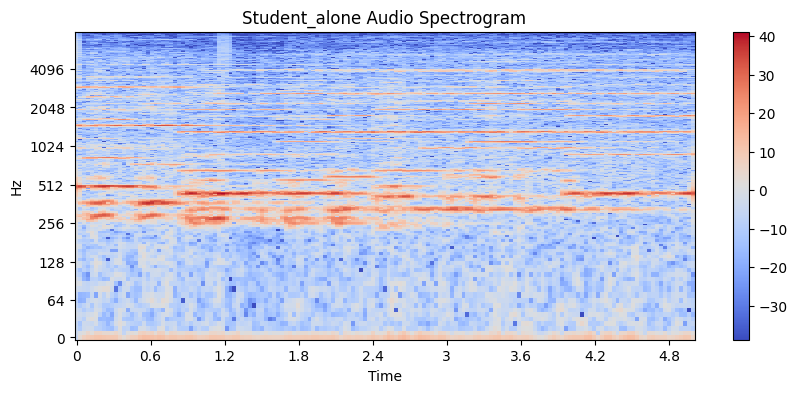

In [ ]:
plot_spectrogram(x_out[1].cpu().permute(1,0).detach().numpy().squeeze()  , title="VQVAE Audio Spectrogram")
plot_spectrogram(x_out2[1].cpu().permute(1,0).detach().numpy().squeeze()  , title="Distilled_vqvae Audio Spectrogram")
plot_spectrogram(x_out3[1].cpu().permute(1,0).detach().numpy().squeeze()  , title="Student_alone Audio Spectrogram")

In [ ]:
print(f"vqvae reconstruction loss: {metrics['recons_loss']} and multispectral loss: {metrics['multispectral_loss']}")
print(f"distilled_vqvae reconstruction loss: {metrics2['recons_loss']} and multispectral loss: {metrics2['multispectral_loss']}")
print(f"student_alone reconstruction loss: {metrics3['recons_loss']} and multispectral loss: {metrics3['multispectral_loss']}")

vqvae reconstruction loss: 1.021641731262207 and multispectral loss: 0.48243746161460876
distilled_vqvae reconstruction loss: 3.2764666080474854 and multispectral loss: 1.9502047300338745
student_alone reconstruction loss: 0.6893479228019714 and multispectral loss: 0.24703644216060638


##Understanding the Impact of Knowledge Distillation and Direct Training

Based on the results, the student-alone model outperforms both the original VQVAE and the distilled version in reconstruction and multispectral loss. This suggests that training the student model directly led to better learning than the knowledge distillation process, which did not effectively transfer useful information from the teacher. The significantly worse performance of the distilled model indicates that something in the distillation process—such as loss weighting or teacher guidance—may have hindered learning.

Given that the student-alone model already surpasses the VQVAE on this dataset, I plan to fine-tune the VQVAE to improve its performance. This could lead to a stronger teacher model, which may help improve the effectiveness of knowledge distillation. Once the fine-tuned VQVAE is trained, I will retry knowledge distillation, ensuring that the student benefits from a better teacher and potentially adjusting the distillation method to enhance learning.

#Fine-tune of VQVAE
The fine-tuning will follow 2 different approaches. Initially I want to freeze the backbone since I expect the layers at the beginning of the encoder learnt some general features, usefull to a dataset similar to the one used during the training of the VQVAE

In [ ]:
def fine_tune_freeze(model):
  for level in range(model.levels):
      encoder = model.encoders[level]
      print(f"Encoder {level}")
      for l, level_block in enumerate(encoder.level_blocks[:-1]):
        print(f"encoder {level} level_block {l} with {sum(p.numel() for p in level_block.parameters())} parameters freezed")
        for param in level_block.parameters():
          param.requires_grad = False
      last_block = encoder.level_blocks[-1]
      print(f"encoder {level} last_block with {sum(p.numel() for p in last_block.model[0].parameters())} parameters freezed")
      for param in last_block.model[0].parameters():
        param.requires_grad = False
      trainable_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
      print(f"Encoder {level} has {trainable_params} trainable parameters on {sum(p.numel() for p in encoder.parameters())}, so the {100 * trainable_params / sum(p.numel() for p in encoder.parameters()):.2f}% of the parameters")


  for level in range(model.levels): # I want to train only the layers near the bottleneck
      print(f"Decoder {level}")
      decoder = model.decoders[level]
      for param in decoder.out.parameters():
        param.requires_grad = False
      for l,level_block in enumerate(decoder.level_blocks[:-1]):
        print(f"decoder {level} level_block {l} with {sum(p.numel() for p in level_block.parameters())} parameters freezed")
        for param in level_block.parameters():
          param.requires_grad = False
      last_level_block = decoder.level_blocks[-1]
      print(f"decoder {level} last_block with {sum(p.numel() for p in last_level_block.model[2:].parameters())} parameters freezed")
      for param in last_level_block.model[2:].parameters(): #the first layer should be trainable
        param.requires_grad = False
      trainable_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
      print(f"Decoder {level} has {trainable_params} trainable parameters on {sum(p.numel() for p in decoder.parameters())}, so the {100 * trainable_params / sum(p.numel() for p in decoder.parameters()):.2f}% of the parameters")


In [ ]:
fine_tuned_vqvae_path = f"{DRIVE_PATH}/checkpoint3/fine_tuned_vqvae.pth"
hps, model = make_my_vqvae(fine_tuned_vqvae_path, 'vqvae')

unfreeze_model(model)

assert all(p.requires_grad for p in model.parameters()), "vqvae model should be trainable"
# train only few layers
fine_tune_freeze(model)

optimizer = optim.Adam(model.parameters(), lr=5e-4) # Lower lr
num_epochs = 7 # Lower number of epochs

# Placeholder for storing losses for each epoch
losses = []
losses_val = []

# Distillation training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0  # To track loss for this epoch

    # Using tqdm for the progress bar
    loop = tqdm(enumerate(train_dataloader), total=len(train_dataloader), leave=True)
    for batch_idx, inputs in loop:
        inputs = model.preprocess(inputs)
        inputs= inputs.to(device)

        x_out, loss, metrics = model(inputs,hps)  # Model's outputs
        # assert x_out.requires_grad, "Model's output does not require grad!"
        # assert loss.requires_grad, "Loss doesn't require grad!"
        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()

        # Apply gradient clipping
        # t.nn.utils.clip_grad_norm_(alone_student.parameters(), max_norm=1.0)

        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Update progress bar with loss and epoch information
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())
    # Calculate average loss for the epoch
    avg_loss = running_loss / batch_idx + 1
    losses.append(avg_loss)

    # Print loss for this epoch
    tqdm.write(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}")

    ####### VALIDATION ########
    model.eval()
    val_loss = 0
    with t.no_grad():
        for batch_idx, inputs in enumerate(val_dataloader):
            inputs = model.preprocess(inputs)
            inputs = inputs.to(device=device)

            x_out, loss, metrics = model(inputs,hps)  # Model's outputs

            val_loss += loss.item()
        # Calculate average loss for the epoch
        avg_val_loss = val_loss / batch_idx + 1
        losses_val.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss:.4f}")
        # if avg val_loss is better than the one before, save the model
        if epoch == 0:
            # create directory if not exist
            os.makedirs(f"{DRIVE_PATH}/checkpoint3", exist_ok=True)
            best_loss = avg_val_loss
            t.save(model.state_dict(), f"{DRIVE_PATH}/checkpoint3/fine_tuned_vqvae.pth")
        elif avg_val_loss < best_loss:
            best_loss = avg_val_loss
            t.save(model.state_dict(), f"{DRIVE_PATH}/checkpoint3/fine_tuned_vqvae.pth")


Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint3/fine_tuned_vqvae.pth', 'levels': 3, 'downs_t': (2, 2, 2), 'strides_t': (2, 2, 2), 'hvqvae_multipliers': (2, 1, 1), 

Epoch [1/7]: 100%|██████████| 212/212 [12:45<00:00,  3.61s/it, loss=1.09]

Epoch [1/7], Average Loss: 2.0330


Validation Loss: 2.0405


Epoch [2/7]: 100%|██████████| 212/212 [12:43<00:00,  3.60s/it, loss=0.874]

...

Epoch [6/7], Average Loss: 1.9594


Validation Loss: 1.9964


Epoch [7/7]: 100%|██████████| 212/212 [12:43<00:00,  3.60s/it, loss=1.19]

Epoch [7/7], Average Loss: 1.9524


Validation Loss: 1.9781


In [ ]:
hps, model = make_my_vqvae(path_vqvae, 'vqvae')

unfreeze_model(model)

assert all(p.requires_grad for p in model.parameters()), "vqvae model should be trainable"
# train only few layers
# fine_tune_freeze(model)

optimizer = optim.Adam(model.parameters(), lr=5e-4) # Lower lr
num_epochs = 4 # Lower number of epochs

# Placeholder for storing losses for each epoch
losses = []
losses_val = []

# Distillation training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0  # To track loss for this epoch

    # Using tqdm for the progress bar
    loop = tqdm(enumerate(train_dataloader), total=len(train_dataloader), leave=True)
    for batch_idx, inputs in loop:
        inputs = model.preprocess(inputs)
        inputs= inputs.to(device)

        x_out, loss, metrics = model(inputs,hps)  # Model's outputs
        # assert x_out.requires_grad, "Model's output does not require grad!"
        # assert loss.requires_grad, "Loss doesn't require grad!"
        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()

        # Apply gradient clipping
        # t.nn.utils.clip_grad_norm_(alone_student.parameters(), max_norm=1.0)

        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Update progress bar with loss and epoch information
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())
    # Calculate average loss for the epoch
    avg_loss = running_loss / batch_idx + 1
    losses.append(avg_loss)

    # Print loss for this epoch
    tqdm.write(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}")

    ####### VALIDATION ########
    model.eval()
    val_loss = 0
    with t.no_grad():
        for batch_idx, inputs in enumerate(val_dataloader):
            inputs = model.preprocess(inputs)
            inputs = inputs.to(device=device)

            x_out, loss, metrics = model(inputs,hps)  # Model's outputs

            val_loss += loss.item()
        # Calculate average loss for the epoch
        avg_val_loss = val_loss / batch_idx + 1
        losses_val.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss:.4f}")
        # if avg val_loss is better than the one before, save the model
        if epoch == 0:
            # create directory if not exist
            os.makedirs(f"{DRIVE_PATH}/checkpoint", exist_ok=True)
            best_loss = avg_val_loss
            t.save(model.state_dict(), f"{DRIVE_PATH}/checkpoint/fine_tuned_vqvae.pth")
        elif avg_val_loss < best_loss:
            best_loss = avg_val_loss
            t.save(model.state_dict(), f"{DRIVE_PATH}/checkpoint/fine_tuned_vqvae.pth")


Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/LQVAE-separation/checkpoint_step_60001_latent.pth.tar', 'levels': 3, 'downs_t': (2, 2, 2), 'strides_t': (2, 2, 2), 'hvqvae_mult

Epoch [1/4]: 100%|██████████| 212/212 [21:18<00:00,  6.03s/it, loss=1.39]

Epoch [1/4], Average Loss: 2.1524


Validation Loss: 2.0254


Epoch [2/4]: 100%|██████████| 212/212 [21:18<00:00,  6.03s/it, loss=0.783]

...

Epoch [3/4], Average Loss: 1.9263


Validation Loss: 1.9301


Epoch [4/4]: 100%|██████████| 212/212 [21:16<00:00,  6.02s/it, loss=0.738]

Epoch [4/4], Average Loss: 1.8673


Validation Loss: 1.8734


#Evaluation of fine tuned vqvae

In [ ]:
fine_tuned_vqvae_path = f"{DRIVE_PATH}/checkpoint/fine_tuned_vqvae_equi.pth"
hps_fine_tuned_vqvae, fine_tuned_vqvae = make_my_vqvae(fine_tuned_vqvae_path, 'vqvae')
fine_tuned_vqvae_path2 = f"{DRIVE_PATH}/checkpoint/fine_tuned_vqvae.pth" #without freezing
hps_fine_tuned_vqvae2, fine_tuned_vqvae2 = make_my_vqvae(fine_tuned_vqvae_path2, 'vqvae')

Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint4/fine_tuned_vqvae_equi.pth', 'levels': 3, 'downs_t': (2, 2, 2), 'strides_t': (2, 2, 2), 'hvqvae_multipliers': (2, 1,

In [ ]:
batch = next(iter(val_dataloader))
batch = batch.to(device)
batch = fine_tuned_vqvae.preprocess(batch)

In [ ]:
%timeit evaluate(fine_tuned_vqvae, batch, hps_fine_tuned_vqvae)

719 ms ± 6.25 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit evaluate(fine_tuned_vqvae2, batch, hps_fine_tuned_vqvae2)

742 ms ± 17.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
with t.no_grad():
  x_out, loss, metrics = fine_tuned_vqvae(batch,hps_fine_tuned_vqvae)
  print(f"vqvae reconstruction loss: {metrics['recons_loss']} and multispectral loss: {metrics['multispectral_loss']}")
  x_out2, loss2, metrics2 = fine_tuned_vqvae2(batch,hps_fine_tuned_vqvae2)
  print(f"vqvae reconstruction loss: {metrics2['recons_loss']} and multispectral loss: {metrics2['multispectral_loss']}")

vqvae reconstruction loss: 0.40868058800697327 and multispectral loss: 0.11554763466119766
vqvae reconstruction loss: 0.34384244680404663 and multispectral loss: 0.12318070977926254


#Distillation with fine tuned teacher

In [ ]:
teacher = fine_tuned_vqvae2  # Pre-trained teacher
hps_student,student = make_my_vqvae(None, 'distilled_vqvae')

# Teacher is frozen
freeze_model(teacher)
assert all(p.requires_grad == False for p in teacher.parameters()), "Teacher model should be frozen"

freeze_model(student)
for param in student.encoders.parameters():
    param.requires_grad = True
assert all(p.requires_grad for p in student.encoders.parameters()), "Student encoders should be trainable"
assert all(p.requires_grad == False for p in student.bottleneck.parameters()), "The bottleneck should be frozen"
assert all(p.requires_grad == False for p in student.decoders.parameters()), "The decoders should be frozen"

# Optimizer for student
optimizer = optim.Adam(student.parameters(), lr=1e-3)
num_epochs = 30

# Placeholder for storing losses for each epoch
losses = []
losses_val = []

# Distillation training loop
for epoch in range(num_epochs):
    student.train()
    running_loss = 0  # To track loss for this epoch

    # Using tqdm for the progress bar
    loop = tqdm(enumerate(train_dataloader), total=len(train_dataloader), leave=True)
    for batch_idx, inputs in loop:
        inputs = vqvae.preprocess(inputs) # teacher.enc already calls preprocess
        inputs = inputs.to(device)

        # Forward pass through teacher and student
        with t.no_grad():
            teacher_outputs = teacher.enc(inputs)  # Teacher's outputs
        student_outputs = student.enc(inputs)  # Student's outputs

        # Compute loss for each encoder and aggregate
        total_loss = sum(F.mse_loss(teacher_outputs[i], student_outputs[i]) for i in range(3)) / 3

        # Backpropagation and optimization
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += total_loss.item()

        # Update progress bar with loss and epoch information
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=total_loss.item())
    # Calculate average loss for the epoch
    avg_loss = running_loss / len(train_dataloader)
    losses.append(avg_loss)

    # Print loss for this epoch
    tqdm.write(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}")

    ####### VALIDATION ########
    student.eval()
    val_loss = 0
    with t.no_grad():
        for data in val_dataloader:
            data = teacher.preprocess(data)
            data = data.to(device=device)

            teacher_outputs = teacher.enc(data)  # Teacher's outputs

            student_outputs = student.enc(data)  # Student's outputs

            total_loss = sum(F.mse_loss(teacher_outputs[i], student_outputs[i]) for i in range(3)) / 3

            val_loss += total_loss.item()
        # Calculate average loss for the epoch
        avg_val_loss = val_loss / len(val_dataloader)
        losses_val.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss:.4f}")
        # if avg val_loss is better than the one before, save the model
        if epoch == 0:
            # create directory if not exist
            os.makedirs(f"{DRIVE_PATH}/checkpoint", exist_ok=True)
            best_loss = avg_val_loss
            t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint/trained_enc_distilled_vqvae.pth")
        elif avg_val_loss < best_loss:
            best_loss = avg_val_loss
            t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint/trained_enc_distilled_vqvae.pth")


Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 4), 'hvqvae_multipliers': (1, 0.5, 0.5), 'revival_threshold': 1.0, 'emb_width': 64, 'l_bins': 2048, 'l_mu': 0.99, 

Epoch [1/30]: 100%|██████████| 214/214 [01:42<00:00,  2.09it/s, loss=0.0495]

Epoch [1/30], Average Loss: 0.3582


Validation Loss: 0.0528


Epoch [2/30]: 100%|██████████| 214/214 [01:43<00:00,  2.08it/s, loss=0.0218]

...

Epoch [29/30], Average Loss: 0.0109


Validation Loss: 0.0109


Epoch [30/30]: 100%|██████████| 214/214 [01:45<00:00,  2.03it/s, loss=0.00595]

Epoch [30/30], Average Loss: 0.0108


Validation Loss: 0.0109


In [ ]:
teacher = fine_tuned_vqvae2  # Pre-trained teacher
trained_distilled_vqvae_path = f"{DRIVE_PATH}/checkpoint/trained_enc_distilled_vqvae.pth"
hps_distilled, student = make_my_vqvae(trained_distilled_vqvae_path, 'distilled_vqvae')
student = student.to(device)
# Teacher is frozen
freeze_model(teacher)
assert all(p.requires_grad == False for p in teacher.parameters()), "Teacher model should be frozen"

freeze_model(student)
student.train() #unfreeze only the decoders to be sure that only they are trainable
for param in student.decoders.parameters():
    param.requires_grad = True
assert all(p.requires_grad for p in student.decoders.parameters()), "Student decoders should be trainable"
assert all(p.requires_grad == False for p in student.bottleneck.parameters()), "The bottleneck should be frozen"
assert all(p.requires_grad == False for p in student.encoders.parameters()), "The encoders should be frozen"

# Optimizer for student
optimizer = optim.Adam(student.parameters(), lr=1e-4)
num_epochs = 30

# Placeholder for storing losses for each epoch
losses = []
losses_val = []

# Distillation training loop
for epoch in range(num_epochs):
    student.train()
    running_loss = 0  # To track loss for this epoch

    # Using tqdm for the progress bar
    loop = tqdm(enumerate(train_dataloader), total=len(train_dataloader), leave=True)
    for batch_idx, inputs in loop:
        inputs = vqvae.preprocess(inputs)
        inputs= inputs.to(device)

        # Forward pass through teacher and student
        with t.no_grad():
            inputs = teacher.enc(inputs)
            _, xs_quantised, _, _ = teacher.bottleneck(inputs)
            teacher_outputs = teacher.dec(xs_quantised)  # Teacher's outputs

        student_outputs = student.dec(xs_quantised)  # Student's outputs

        # Compute loss for each encoder and aggregate
        loss_total = sum(F.mse_loss(teacher_outputs[i], student_outputs[i]) for i in range(3)) / 3

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss_total.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += loss_total.item()

        # Update progress bar with loss and epoch information
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss_total.item())
    # Calculate average loss for the epoch
    avg_loss = running_loss / len(train_dataloader)
    losses.append(avg_loss)

    # Print loss for this epoch
    tqdm.write(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.7f}")

    ####### VALIDATION ########
    student.eval()
    val_loss = 0
    with t.no_grad():
        for data in val_dataloader:
            data = vqvae.preprocess(data)
            data = data.to(device=device)



            inputs = teacher.enc(data)
            _, xs_quantised, _, _ = teacher.bottleneck(inputs)
            teacher_outputs = teacher.dec(xs_quantised)  # Teacher's outputs

            student_outputs = student.dec(xs_quantised)  # Student's outputs

            loss_total = sum(F.mse_loss(teacher_outputs[i], student_outputs[i]) for i in range(3)) / 3

            val_loss += loss_total.item()
        # Calculate average loss for the epoch
        avg_val_loss = val_loss / len(val_dataloader)
        losses_val.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss:.7f}")
        # if avg val_loss is better than the one before, save the model
        if epoch == 0:
            # create directory if not exist
            os.makedirs(f"{DRIVE_PATH}/checkpoint4", exist_ok=True)
            best_loss = avg_val_loss
            t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint4/trained_dec_distilled_vqvae.pth")
        elif avg_val_loss < best_loss:
            best_loss = avg_val_loss
            t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint4/trained_dec_distilled_vqvae.pth")


Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint4/trained_enc_distilled_vqvae.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 4), 'hvqvae_multipliers': 

Epoch [1/30]: 100%|██████████| 201/201 [02:07<00:00,  1.58it/s, loss=7.31e-5]

Epoch [1/30], Average Loss: 0.0020736


Validation Loss: 0.0001959


Epoch [2/30]: 100%|██████████| 201/201 [02:08<00:00,  1.56it/s, loss=8.4e-5]

...

Epoch [29/30], Average Loss: 0.0000377


Validation Loss: 0.0000442


Epoch [30/30]: 100%|██████████| 201/201 [02:07<00:00,  1.58it/s, loss=0.00011]

Epoch [30/30], Average Loss: 0.0000391


Validation Loss: 0.0000570


In [ ]:
student.bottleneck.load_state_dict(fine_tuned_vqvae2.bottleneck.state_dict())

<All keys matched successfully>

In [ ]:
t.save(student.state_dict(), f"{DRIVE_PATH}/checkpoint/final_trained_distilled_vqvae.pth")

#Evaluation of the performance(NEW)
Let's assess distilled and student_alone performances by comparing it to the teacher model in terms of accuracy and efficiency.

In [ ]:
trained_distilled_vqvae_path = f"{DRIVE_PATH}/checkpoint/final_trained_distilled_vqvae.pth"
trained_student_alone_path = f"{DRIVE_PATH}/checkpoint/trained_student_alone.pth"
hps_distilled, distilled_vqvae = make_my_vqvae(trained_distilled_vqvae_path, 'distilled_vqvae')
hps_student_alone, student_alone = make_my_vqvae(trained_student_alone_path, 'distilled_vqvae')

Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint4/final_trained_distilled_vqvae.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 4), 'hvqvae_multipliers'

In [ ]:
batch = next(iter(val_dataloader))
batch = batch.to(device)
batch = vqvae.preprocess(batch)

In [ ]:
@t.no_grad()
def evaluate(model, batch, hps):
  return model(batch, hps)

In [ ]:
%timeit evaluate(fine_tuned_vqvae2, batch, hps_fine_tuned_vqvae2)

780 ms ± 61 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit evaluate(distilled_vqvae, batch, hps_distilled)

397 ms ± 3.24 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%timeit evaluate(student_alone, batch, hps_student_alone)

330 ms ± 2.64 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
with t.no_grad():
  x_out2, loss2, metrics2 = distilled_vqvae(batch,hps_distilled)
  x_out, loss, metrics = fine_tuned_vqvae2(batch,hps_fine_tuned_vqvae2)
  x_out3, loss3, metrics3 = student_alone(batch,hps_student_alone)
  print(x_out[1])
  print(hps_distilled.sr)
  dst_path = "/content/reconstruction"
  os.makedirs(dst_path, exist_ok=True)
  torchaudio.save(f'{dst_path}/teacher_rec_0.wav', x_out[1].cpu().permute(1,0), sample_rate=hps.sr)
  torchaudio.save(f'{dst_path}/distilled_vqvae_rec_0.wav', x_out2[1].cpu().permute(1,0), sample_rate=hps_distilled.sr)
  torchaudio.save(f'{dst_path}/student_alone_rec_0.wav', x_out3[1].cpu().permute(1,0), sample_rate=hps_distilled.sr)



tensor([[-1.3631e-02],
        [-9.0689e-03],
        [ 4.0971e-05],
        ...,
        [-1.3839e-02],
        [-3.4538e-02],
        [-2.2179e-02]], device='cuda:0')
16000


In [ ]:
import os
from IPython.display import display, HTML

teacher_rec = "/content/reconstruction/teacher_rec_0.wav"
distilled_vqvae_rec = "/content/reconstruction/distilled_vqvae_rec_0.wav"
student_alone_rec = "/content/reconstruction/student_alone_rec_0.wav"

# Check if file exists
if os.path.exists(teacher_rec):
    print(f"File found: {teacher_rec}")
else:
    print(f"File NOT found: {teacher_rec}")

from IPython.display import Audio, display

display(Audio(teacher_rec, autoplay=False))
display(Audio(distilled_vqvae_rec, autoplay=False))
display(Audio(student_alone_rec, autoplay=False))

File found: /content/reconstruction/teacher_rec_0.wav


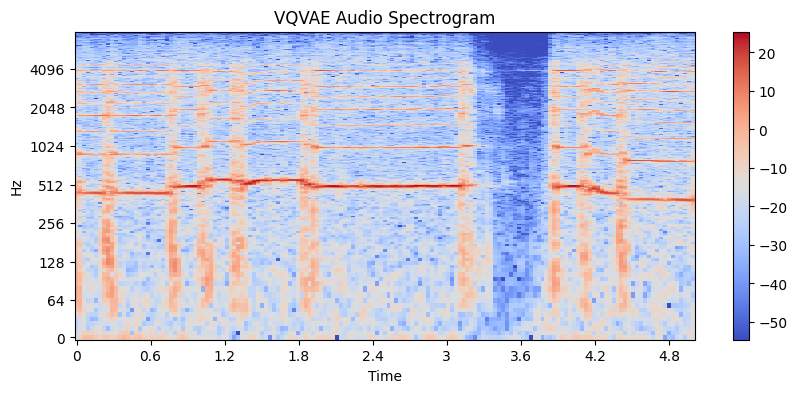

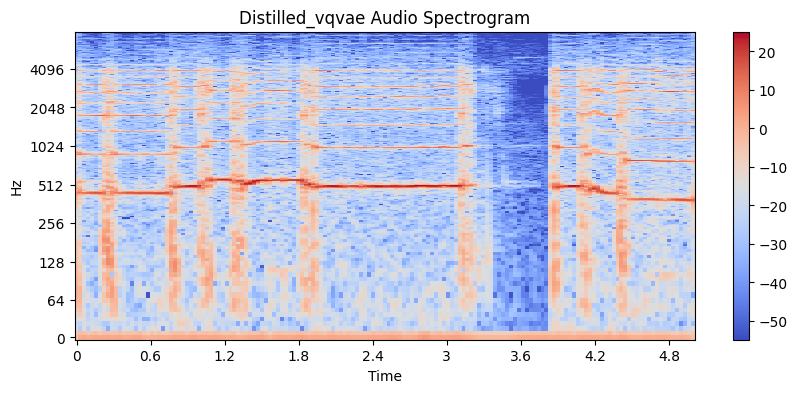

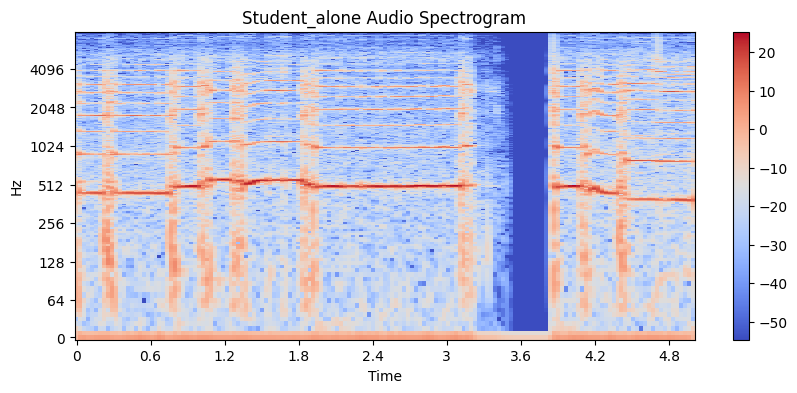

In [ ]:
plot_spectrogram(x_out[1].cpu().permute(1,0).detach().numpy().squeeze()  , title="VQVAE Audio Spectrogram")
plot_spectrogram(x_out2[1].cpu().permute(1,0).detach().numpy().squeeze()  , title="Distilled_vqvae Audio Spectrogram")
plot_spectrogram(x_out3[1].cpu().permute(1,0).detach().numpy().squeeze()  , title="Student_alone Audio Spectrogram")

In [ ]:
print(f"vqvae reconstruction loss: {metrics['recons_loss']} and multispectral loss: {metrics['multispectral_loss']}")
print(f"distilled_vqvae reconstruction loss: {metrics2['recons_loss']} and multispectral loss: {metrics2['multispectral_loss']}")
print(f"student_alone reconstruction loss: {metrics3['recons_loss']} and multispectral loss: {metrics3['multispectral_loss']}")

vqvae reconstruction loss: 0.5846303701400757 and multispectral loss: 0.20580296218395233
distilled_vqvae reconstruction loss: 2.4960858821868896 and multispectral loss: 1.5339791774749756
student_alone reconstruction loss: 0.6024166941642761 and multispectral loss: 0.2122001200914383


### Observations on Model Performance  

There has been an improvement in both the fine-tuned teacher model and the student trained with it. However, the results of the distilled model are still far from those of the standalone student model.  

This suggests that using only the reconstruction loss based on the teacher's soft labels is not sufficient. In the future, it might be worth exploring the introduction of a correspondence between the feature maps of the internal layers in both the encoder and decoder.  


# Experiment: Audio Source Separation via Bayesian Inference  

In this experiment, I aim to test the models on the task of **Audio Source Separation via Bayesian Inference in the Latent Domain** [Mancusi et al., 2022].  

Several modifications were made compared to the original configuration suggested in the paper's GitHub repository. These include maintaining the sample rate at **22 kHz**, training the **LQVAE** and priors accordingly, and precomputing the **codebook**. Given these changes, I do not expect the models to perform as well as the original.  

However, the key goal of this experiment is to evaluate whether the **fine-tuned model**, the **distilled model**, and the **standalone student** can retain the original model's ability to separate an audio mixture.  

To gain a broader perspective, I will conduct the experiment using both the **input data from the original paper** and an **input sample from the evaluation split of my dataset**.


In [ ]:
class AudioProcessingConfig:
    def __init__(self):
        self.vqvae_config = 'vqvae'
        self.path_1 = './script/data/drums/validation/Track01510.wav'
        self.path_2 = './script/data/bass/validation/Track01510.wav'
        self.shift = 10.0
        self.bs = 64
        self.sample_tokens = 1024
        self.sigma = 0.4
        self.alpha = [0.5, 0.5]
        self.raw_to_tokens = 64
        self.l_bins = 2048
        self.levels = 3
        self.level = 2
        self.sample_rate = 22050
        self.bs_chunks = 1
        self.chunk_size = 32
        self.window_mode = 'constant'
        self.downs_t = (2, 2, 2)
        self.context = 50
        self.top_k_posterior = 0
        self.time_likelihood = False
        self.delta_likelihood = False
        self.restore_priors = [path_prior_0, path_prior_1]
        self.restore_vqvae = path_vqvae
        self.sum_codebook = path_codebook
        self.save_path = '/content/results'
        self.commit = 1.0
        self.emb_width = 64

    def __repr__(self):
        return f"AudioProcessingConfig({self.__dict__})"

# Create an instance
config = AudioProcessingConfig()
print(config)


In [ ]:
os.makedirs("results", exist_ok=True)

Using cuda True
vqvae
Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/LQVAE-separation/checkpoint_step_60001_latent.pth.tar', 'levels': 3, 'downs_t': (2, 2, 2), 'strides_t': (

100%|██████████| 64/64 [00:01<00:00, 63.14it/s]


sigma_rejection = 0.9692487120628357
global prior test: tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]])
marginal_0_sorted = tensor([0.0001, 0.0002, 0.0004, 0.0004, 0.0004, 0.0005, 0.0008, 0.0008, 0.0009,
        0.0012, 0.0013, 0.0014, 0.0016, 0.0017, 0.0018, 0.0019, 0.0020, 0.0025,
        0.0026, 0.0026, 0.0028, 0.0029, 0.0032, 0.0044, 0.0051, 0.0053, 0.0060,
        0.0072, 0.0075, 0.0075, 0.0080, 0.0089, 0.0090, 0.0101, 0.0104, 0.0106,
        0.0111, 0.0115, 0.0167, 0.0171, 0.0178, 0.0192, 0.0195, 0.0200, 0.0208,
        0.0214, 0.0214, 0.0218, 0.0219, 0.0221, 0.0225, 0.0249, 0.0251, 0.0259,
        0.0278, 0.0337, 0.0355, 0.0376, 0.0395, 0.0407, 0.0450, 0.0612, 0.0692,
        0.1149])
marginal_1_sorted = t

<Figure size 640x480 with 0 Axes>

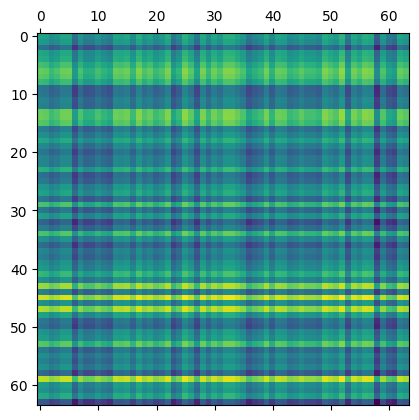

<Figure size 640x480 with 0 Axes>

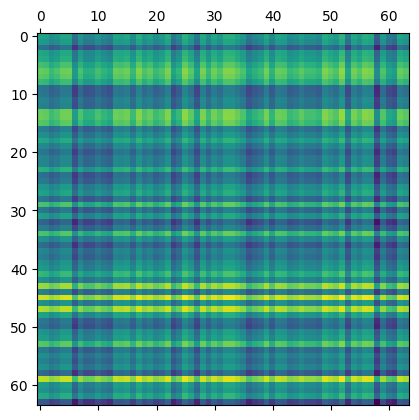

<Figure size 640x480 with 0 Axes>

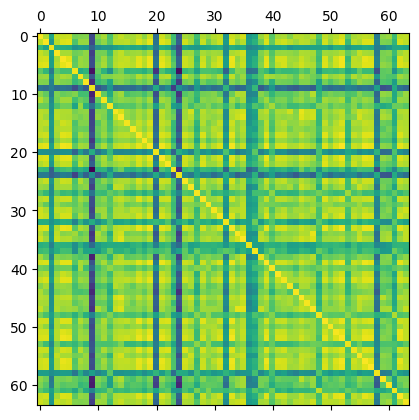

<Figure size 640x480 with 0 Axes>

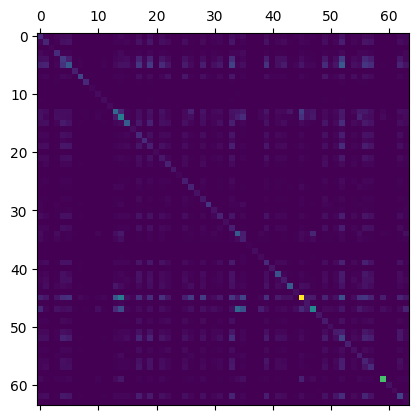

In [ ]:
separate(config)

In [ ]:
config.restore_vqvae = f"{DRIVE_PATH}/checkpoint/fine_tuned_vqvae.pth"
config.save_path = '/content/results2'

In [ ]:
os.makedirs("results2", exist_ok=True)

Using cuda True
vqvae
Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint4/fine_tuned_vqvae.pth', 'levels': 3, 'downs_t': (2, 2, 2), 'strides_t': (2, 2, 2), 'hvqvae_mul

100%|██████████| 64/64 [00:00<00:00, 66.33it/s]


sigma_rejection = 1.834686279296875
global prior test: tensor([[ True, False, False,  ...,  True, False, False],
        [ True, False, False,  ...,  True, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ...,  True, False, False],
        [ True, False, False,  ...,  True, False, False],
        [False,  True,  True,  ..., False,  True,  True]])
marginal_0_sorted = tensor([1.0464e-05, 1.1208e-05, 1.3366e-05, 2.9999e-05, 3.3930e-05, 4.2112e-05,
        7.1858e-05, 1.4916e-04, 1.5475e-04, 2.2676e-04, 3.0281e-04, 3.2924e-04,
        3.4409e-04, 3.9636e-04, 4.1838e-04, 4.2128e-04, 4.3822e-04, 4.4066e-04,
        4.4397e-04, 4.8974e-04, 4.9231e-04, 5.1596e-04, 5.7283e-04, 7.1890e-04,
        8.2683e-04, 8.5339e-04, 1.0002e-03, 1.0018e-03, 1.2011e-03, 1.2548e-03,
        1.3239e-03, 1.4816e-03, 1.5355e-03, 1.6061e-03, 1.6569e-03, 1.9213e-03,
        1.9718e-03, 1.9846e-03, 2.0174e-03, 2.0184e-03, 2.2281e-03, 2.2545e-03,
   

<Figure size 640x480 with 0 Axes>

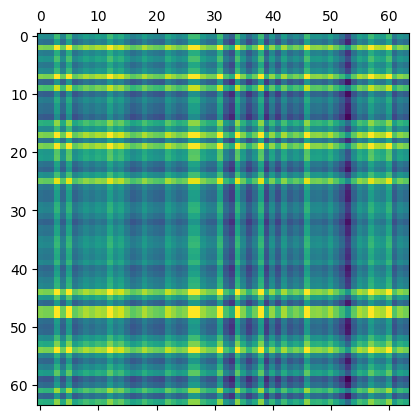

<Figure size 640x480 with 0 Axes>

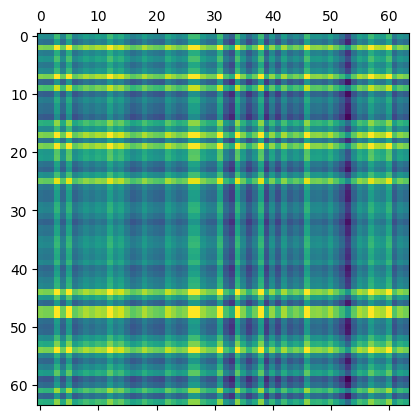

<Figure size 640x480 with 0 Axes>

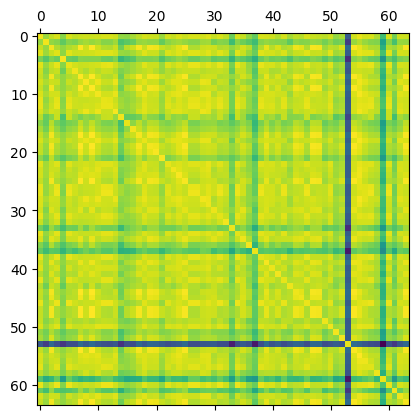

<Figure size 640x480 with 0 Axes>

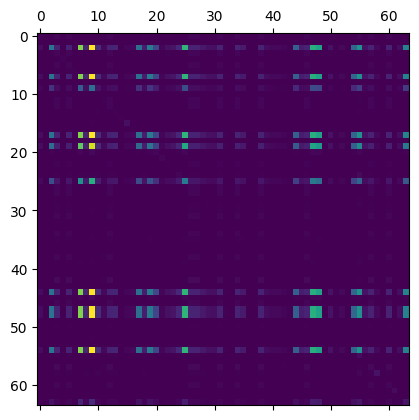

In [ ]:
separate(config)

In [ ]:
config.restore_vqvae = f"{DRIVE_PATH}/checkpoin4/final_trained_distilled_vqvae.pth"
config.vqvae_conf = "distilled_vqvae"
config.downs_t = (1, 1, 1)
config.save_path = '/content/results3'
os.makedirs("results3", exist_ok=True)

Using cuda True
distilled_vqvae
Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint3/trained_student_alone.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 

100%|██████████| 64/64 [00:00<00:00, 90.56it/s]


sigma_rejection = 0.36887577176094055
global prior test: tensor([[False, False, False,  ..., False,  True, False],
        [False,  True, False,  ..., False,  True,  True],
        [ True, False,  True,  ...,  True,  True, False],
        ...,
        [False, False, False,  ..., False,  True,  True],
        [ True,  True,  True,  ...,  True, False,  True],
        [ True,  True,  True,  ...,  True,  True,  True]])
marginal_0_sorted = tensor([7.3236e-08, 1.6547e-07, 9.8359e-07, 1.5157e-06, 2.3684e-06, 2.4357e-06,
        3.9114e-06, 5.0060e-06, 9.5491e-06, 1.2319e-05, 1.9700e-05, 2.0383e-05,
        9.7718e-05, 1.8870e-04, 2.5239e-04, 3.5517e-04, 5.1049e-04, 5.1818e-04,
        5.2954e-04, 5.5585e-04, 5.9620e-04, 7.0774e-04, 8.6398e-04, 9.9146e-04,
        1.1021e-03, 1.1119e-03, 1.2577e-03, 1.3967e-03, 1.4367e-03, 1.9150e-03,
        1.9882e-03, 2.1244e-03, 2.2305e-03, 2.6836e-03, 2.7738e-03, 3.1166e-03,
        3.3543e-03, 3.5698e-03, 3.7749e-03, 4.0657e-03, 6.7244e-03, 7.9184e-03,
 

<Figure size 640x480 with 0 Axes>

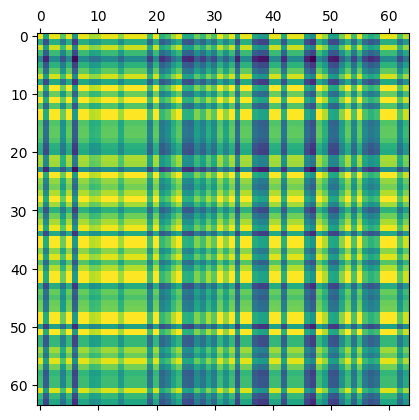

<Figure size 640x480 with 0 Axes>

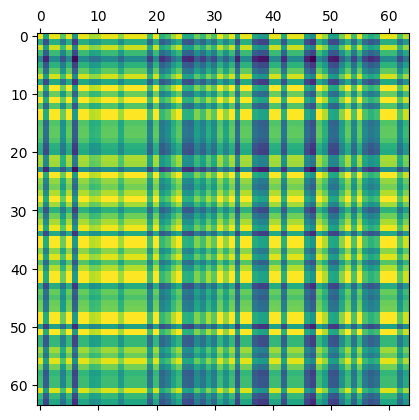

<Figure size 640x480 with 0 Axes>

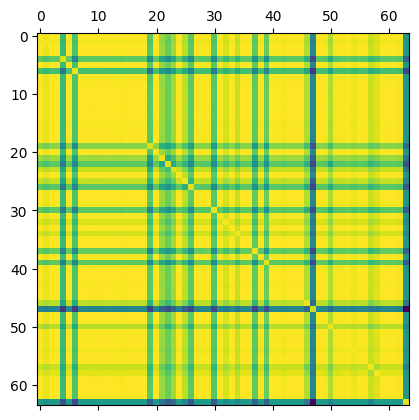

<Figure size 640x480 with 0 Axes>

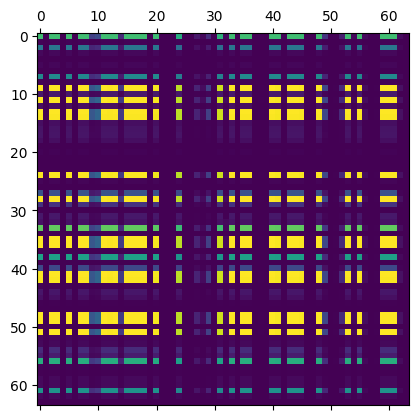

In [ ]:
separate(config)

In [ ]:
config.restore_vqvae = f"{DRIVE_PATH}/checkpoint3/trained_student_alone.pth"
config.save_path = '/content/results4'
os.makedirs("results4", exist_ok=True)

Using cuda True
distilled_vqvae
Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint3/trained_student_alone.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 

100%|██████████| 64/64 [00:00<00:00, 89.34it/s]


sigma_rejection = 0.34680333733558655
global prior test: tensor([[ True, False, False,  ..., False,  True, False],
        [ True,  True, False,  ...,  True, False,  True],
        [ True, False, False,  ..., False,  True, False],
        ...,
        [False, False,  True,  ..., False,  True, False],
        [ True,  True, False,  ...,  True, False,  True],
        [False, False,  True,  ..., False,  True, False]])
marginal_0_sorted = tensor([2.0658e-07, 2.1081e-07, 4.0561e-07, 9.6696e-07, 3.6254e-06, 1.1522e-05,
        1.2546e-05, 1.3828e-05, 7.6223e-05, 7.8974e-05, 1.2454e-04, 1.4311e-04,
        2.0831e-04, 4.0261e-04, 6.1184e-04, 6.9938e-04, 9.8706e-04, 1.0494e-03,
        1.0696e-03, 1.0880e-03, 1.1432e-03, 1.2356e-03, 1.3648e-03, 1.4978e-03,
        2.0185e-03, 2.1010e-03, 2.1108e-03, 2.2652e-03, 2.2728e-03, 2.9459e-03,
        3.0394e-03, 3.0932e-03, 3.2636e-03, 3.3630e-03, 3.3669e-03, 3.5395e-03,
        3.6421e-03, 3.7572e-03, 4.1551e-03, 4.4066e-03, 5.1797e-03, 5.2739e-03,
 

<Figure size 640x480 with 0 Axes>

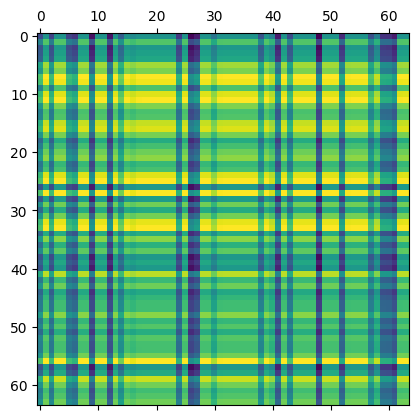

<Figure size 640x480 with 0 Axes>

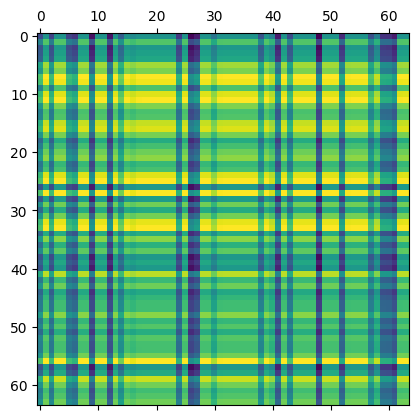

<Figure size 640x480 with 0 Axes>

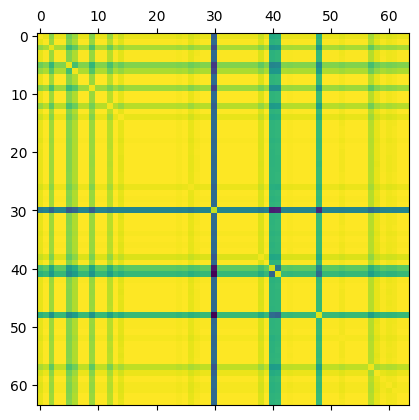

<Figure size 640x480 with 0 Axes>

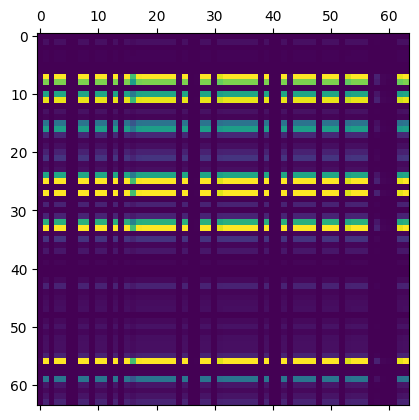

In [ ]:
separate(config)

In [ ]:
config.vqvae_config = 'vqvae'
config.path_1 = '/content/babyslakh_16k/Track00014/stems/S00.wav'
config.path_2 = '/content/babyslakh_16k/Track00014/stems/S01.wav'
config.sample_rate=16000

In [ ]:
os.makedirs("results5", exist_ok=True)

Using cuda True
vqvae
Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/LQVAE-separation/checkpoint_step_60001_latent.pth.tar', 'levels': 3, 'downs_t': (2, 2, 2), 'strides_t': (

100%|██████████| 64/64 [00:00<00:00, 91.80it/s]


sigma_rejection = 0.6818355321884155
global prior test: tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]])
marginal_0_sorted = tensor([0.0004, 0.0008, 0.0011, 0.0016, 0.0016, 0.0018, 0.0022, 0.0025, 0.0025,
        0.0026, 0.0027, 0.0028, 0.0028, 0.0030, 0.0030, 0.0032, 0.0032, 0.0035,
        0.0037, 0.0040, 0.0044, 0.0045, 0.0045, 0.0045, 0.0047, 0.0047, 0.0056,
        0.0058, 0.0060, 0.0072, 0.0073, 0.0087, 0.0090, 0.0090, 0.0094, 0.0097,
        0.0099, 0.0112, 0.0136, 0.0141, 0.0150, 0.0152, 0.0156, 0.0157, 0.0157,
        0.0172, 0.0197, 0.0220, 0.0220, 0.0226, 0.0230, 0.0236, 0.0245, 0.0260,
        0.0278, 0.0285, 0.0311, 0.0483, 0.0489, 0.0614, 0.0619, 0.0677, 0.0695,
        0.0744])
marginal_1_sorted = t

<Figure size 640x480 with 0 Axes>

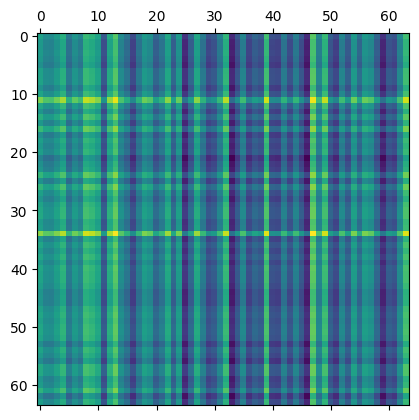

<Figure size 640x480 with 0 Axes>

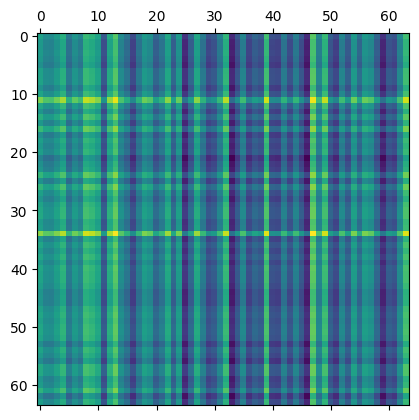

<Figure size 640x480 with 0 Axes>

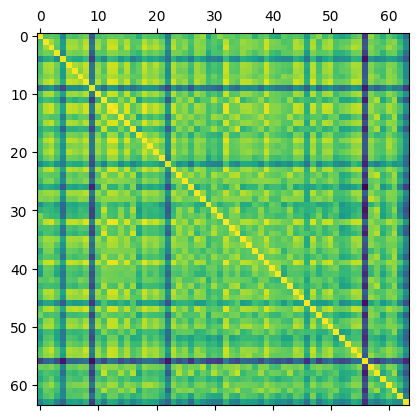

<Figure size 640x480 with 0 Axes>

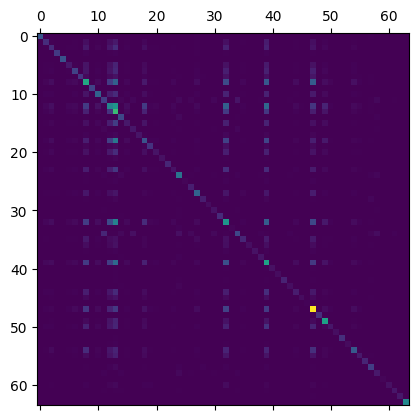

In [ ]:
separate(config)

In [ ]:
config.restore_vqvae = f"{DRIVE_PATH}/checkpoint/fine_tuned_vqvae.pth"
config.save_path = '/content/results6'

In [ ]:
os.makedirs("results6", exist_ok=True)

Using cuda True
vqvae
Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint4/fine_tuned_vqvae.pth', 'levels': 3, 'downs_t': (2, 2, 2), 'strides_t': (2, 2, 2), 'hvqvae_mul

100%|██████████| 64/64 [00:00<00:00, 87.72it/s]


sigma_rejection = 1.8937064409255981
global prior test: tensor([[ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        ...,
        [ True,  True,  True,  ..., False,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True]])
marginal_0_sorted = tensor([1.0986e-06, 1.2646e-06, 3.9082e-06, 4.8626e-06, 4.8914e-06, 5.0509e-06,
        6.1076e-06, 1.0291e-05, 1.1407e-05, 1.4013e-05, 1.8729e-05, 1.8971e-05,
        2.0671e-05, 2.1160e-05, 2.8448e-05, 3.2312e-05, 4.2977e-05, 5.9350e-05,
        1.0255e-04, 2.1429e-04, 2.2649e-04, 3.3025e-04, 3.3927e-04, 3.5476e-04,
        3.8880e-04, 4.1171e-04, 5.4883e-04, 6.9867e-04, 7.0936e-04, 7.1878e-04,
        7.8453e-04, 8.0436e-04, 8.1345e-04, 8.6108e-04, 9.1245e-04, 9.7336e-04,
        1.1118e-03, 1.2703e-03, 1.2889e-03, 1.4257e-03, 1.4934e-03, 1.5320e-03,
  

<Figure size 640x480 with 0 Axes>

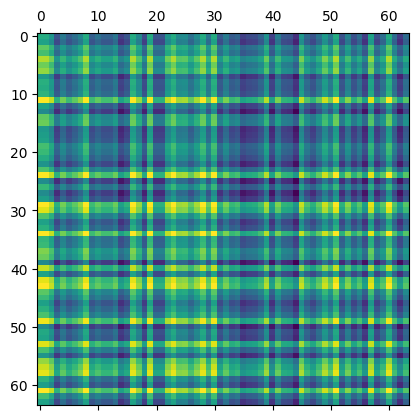

<Figure size 640x480 with 0 Axes>

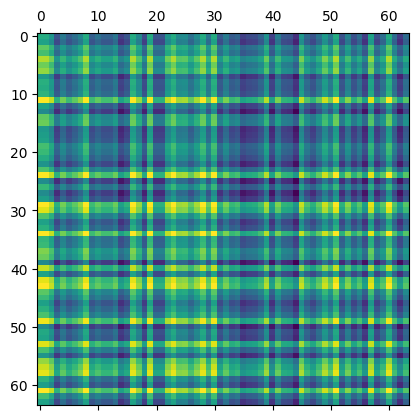

<Figure size 640x480 with 0 Axes>

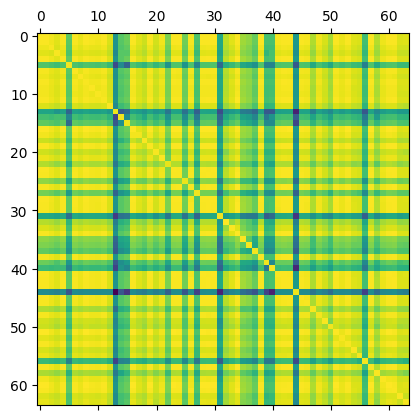

<Figure size 640x480 with 0 Axes>

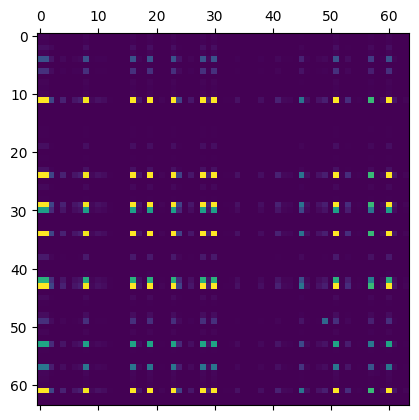

In [ ]:
separate(config)

In [ ]:
config.restore_vqvae = f"{DRIVE_PATH}/checkpoint/final_trained_distilled_vqvae.pth"
config.vqvae_conf = "distilled_vqvae"
config.downs_t = (1, 1, 1)
config.save_path = '/content/results7'
os.makedirs("results7", exist_ok=True)

Using cuda True
distilled_vqvae
Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint4/final_trained_distilled_vqvae.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t':

100%|██████████| 64/64 [00:00<00:00, 93.04it/s]


sigma_rejection = 0.004701793659478426
global prior test: tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]])
marginal_0_sorted = tensor([3.9886e-07, 4.6837e-07, 6.5368e-07, 6.7480e-07, 1.8232e-06, 3.4694e-06,
        8.3047e-06, 1.1561e-05, 1.9347e-05, 2.1252e-05, 4.7626e-05, 7.0939e-05,
        1.2215e-04, 3.0457e-04, 3.1667e-04, 3.4175e-04, 3.6388e-04, 3.9356e-04,
        4.0798e-04, 7.1466e-04, 7.1884e-04, 8.4592e-04, 9.6967e-04, 1.0718e-03,
        1.3442e-03, 1.6322e-03, 1.8915e-03, 1.9839e-03, 2.1236e-03, 2.4192e-03,
        2.4721e-03, 2.5377e-03, 2.5706e-03, 3.0293e-03, 3.3383e-03, 3.6762e-03,
        3.9857e-03, 4.4577e-03, 4.5259e-03, 5.1825e-03, 6.1820e-03, 6.8153e-03,
        6.9187e-03, 7.7124e-03, 9.24

<Figure size 640x480 with 0 Axes>

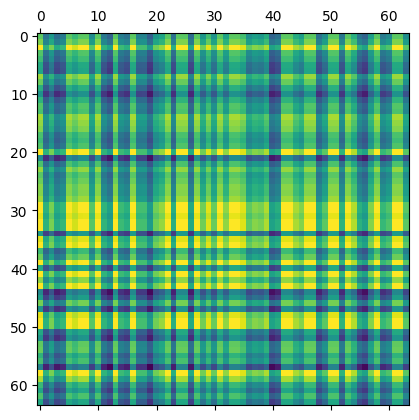

<Figure size 640x480 with 0 Axes>

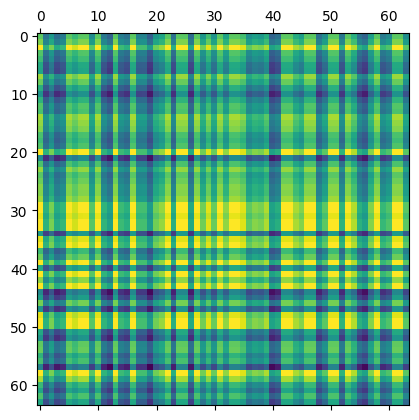

<Figure size 640x480 with 0 Axes>

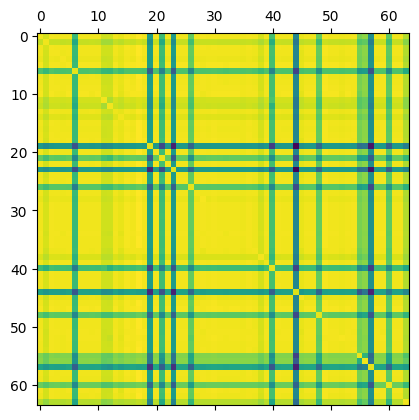

<Figure size 640x480 with 0 Axes>

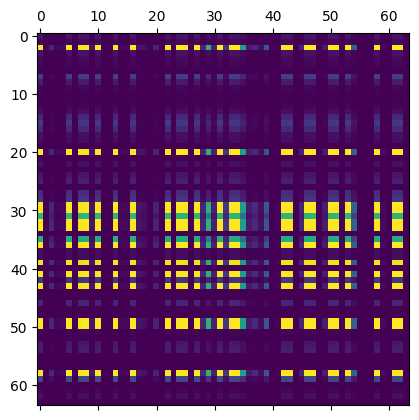

In [ ]:
separate(config)

In [ ]:
config.restore_vqvae = f"{DRIVE_PATH}/checkpoint3/trained_student_alone.pth"
config.save_path = '/content/results8'
os.makedirs("results8", exist_ok=True)

Using cuda True
distilled_vqvae
Using hparams: {'rcall_command': '<unknown_rcall_command>', 'git_commit': '<unknown_git_commit>', 'name': '', 'debug_mem': False, 'debug_eval_files': False, 'debug_speed': False, 'debug_iters': 100, 'debug_batch': False, 'debug_grad_accum': False, 'debug_inputs': False, 'local_path': '', 'local_logdir': 'logs', 'max_len': 24, 'max_log': 32, 'save': True, 'save_iters': 5000, 'seed': 0, 'prior': False, 'log_steps': 100, 'func': '', 'audio_files_dir': '', 'test_audio_files_dir': '', 'finetune': '', 'english_only': False, 'bs': 1, 'bs_sample': 1, 'nworkers': 1, 'aug_shift': False, 'aug_blend': False, 'train_test_split': 0.9, 'train_shrink_factor': 1.0, 'test_shrink_factor': 1.0, 'p_unk': 0.1, 'min_duration': None, 'max_duration': None, 'n_tokens': 0, 'n_vocab': 0, 'use_tokens': False, 'curr_epoch': -1, 'restore_vqvae': '/content/drive/MyDrive/Deep Learning/Project/checkpoint3/trained_student_alone.pth', 'levels': 3, 'downs_t': (1, 1, 1), 'strides_t': (4, 4, 

100%|██████████| 64/64 [00:00<00:00, 89.43it/s]


sigma_rejection = 0.39136621356010437
global prior test: tensor([[ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True, False],
        [ True,  True,  True,  ...,  True,  True,  True],
        ...,
        [ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True, False],
        [ True,  True,  True,  ...,  True,  True,  True]])
marginal_0_sorted = tensor([8.6703e-08, 1.0606e-07, 1.5918e-07, 1.7427e-07, 1.6018e-06, 2.4113e-06,
        2.9803e-06, 3.9902e-06, 4.0841e-05, 4.1720e-05, 1.3992e-04, 4.4727e-04,
        5.1247e-04, 5.2172e-04, 5.7338e-04, 6.1805e-04, 6.2950e-04, 6.8936e-04,
        7.8129e-04, 8.1882e-04, 9.1751e-04, 1.0063e-03, 1.0211e-03, 1.1078e-03,
        1.1242e-03, 1.1871e-03, 1.2522e-03, 1.4859e-03, 1.6201e-03, 1.7338e-03,
        1.7912e-03, 1.8633e-03, 1.8810e-03, 1.9002e-03, 1.9276e-03, 2.0226e-03,
        2.2054e-03, 2.3233e-03, 2.3619e-03, 2.7500e-03, 2.7855e-03, 3.8231e-03,
 

<Figure size 640x480 with 0 Axes>

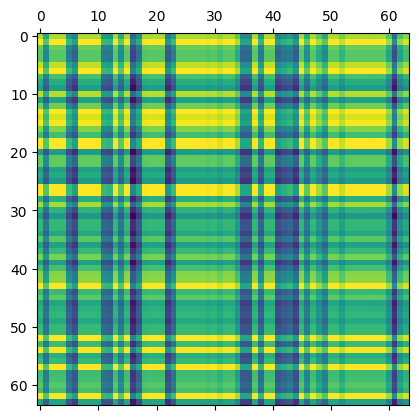

<Figure size 640x480 with 0 Axes>

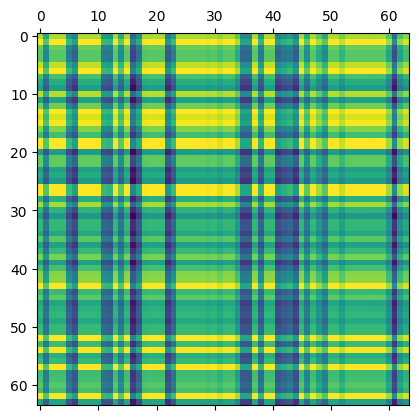

<Figure size 640x480 with 0 Axes>

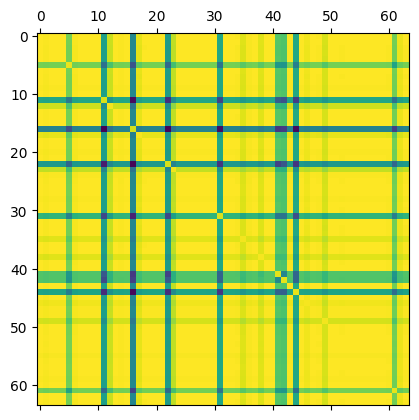

<Figure size 640x480 with 0 Axes>

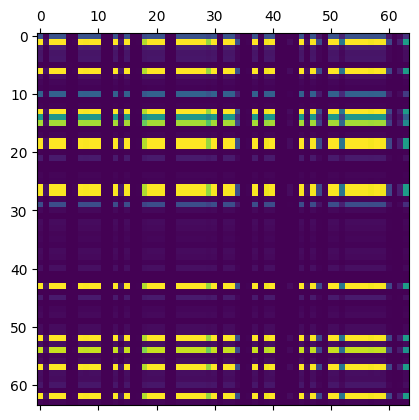

In [ ]:
separate(config)